<img src="images/logo/selene-logo-640.png" style="max-height:75px;" alt="SELENE Logo" />

**Disclaimer:** This Jupyter Notebook contains content generated with the assistance of AI. While every effort has been made to review and validate the outputs, users should independently verify critical information before relying on it. The SELENE notebook repository is constantly evolving. We recommend downloading or pulling the latest version of this notebook from Github.

# Moving Average (MA) Models for Time Series Analysis

**Moving Average (MA) models** are one of the fundamental statistical approaches for modeling time series. Rather than explaining the current value of a series through previous observations, as in an Autoregressive (AR) model, an MA model describes it in terms of current and previous **random shocks or innovations**. This provides a useful way of modeling processes in which unexpected events influence observations for a limited period of time before their effects disappear.

MA models are inherently **statistical models**: they describe the probabilistic dependence between observations rather than providing a deterministic rule for how a time series evolves. Understanding them therefore involves several important statistical concepts, including stationarity, white-noise shocks, autocorrelation, likelihood-based parameter estimation, and invertibility. While some of these concepts make MA models less straightforward to estimate than basic AR models, they provide important insights into how temporal dependencies can arise from unobserved random disturbances.

The importance of MA models extends well beyond using them as standalone forecasting models. Together with AR models, they form the **building blocks of more sophisticated time-series models**, including ARMA, ARIMA, and SARIMA. These models combine autoregressive dynamics, moving-average effects, differencing, and seasonality to represent a much broader range of real-world time series. A solid understanding of the fundamental ideas behind MA models is therefore an important step before advancing to these more flexible and practically useful approaches.

This notebook develops these concepts from the ground up, emphasizing both the **intuition and the underlying mathematics**. By examining how shocks propagate through a time series, how MA parameters determine its autocorrelation structure, why invertibility matters, and how the parameters can be estimated from observed data, we establish the conceptual foundation needed to understand and apply more advanced time-series models with confidence. The notebook also includes a pure Python/NumPy implementation to fit MA models for a more hands-on learning experience.

### Setting up the Notebook

#### Make Required Imports

This notebook requires the import of different Python packages but also additional Python modules that are part of the repository. If a package is missing, use your preferred package manager (e.g., [conda](https://anaconda.org/anaconda/conda) or [pip](https://pypi.org/project/pip/)) to install it. If the code cell below runs with any errors, all required packages and modules have successfully been imported.

In [1]:
from src.utils.libimports.tsa import *
from src.utils.plotting.tsa import *
from src.utils.data.files import *

#### Download Required Data

Some code examples in this notebook use data that first need to be downloaded by running the code cell below. If this code cell throws any error, please check the configuration file `config.yaml` if the URL for downloading datasets is up to date and matches the one on Github. If not, simply download or pull the latest version from Github.

In [2]:
file_orders, _ = download_dataset("tabular/timeseries/tsa-example-daily-orders.csv")

File 'data/datasets/tabular/timeseries/tsa-example-daily-orders.csv' already exists (use 'overwrite=True' to overwrite it).


#### Prerequisites

* This notebook assumes a basic understanding of time series analysis, particularly regarding the characteristics of times such as stationarity, stability, trends, cycles, outliers, and structural breaks.
* While not crucial, some familiarity with Autoregressive (AR) models for time series are recommended. AR models are conceptually simpler and a direct comparison helps to understand the intrinsic characteristics of MA models.

---

## Motivating Example

For a small online shop, knowing approximately **how many orders to expect over the next few days** can be important for managing inventory, replenishing stock, and avoiding both shortages and unnecessary excess inventory. Although daily order volumes may fluctuate around a relatively stable level, they can also be affected by unexpected changes in demand. For example, a viral social-media mention, an outage at a competitor, or unusual weather may suddenly cause substantially more or fewer customers to place orders.

Such unexpected demand shocks often have their **strongest effect immediately and then gradually fade over the following days**. A viral post, for example, may generate a large increase in orders today, a smaller increase tomorrow, and only a modest effect a few days later before its influence disappears. This type of short-lived dependence provides a natural motivation for an $\text{MA}(q)$ model, which represents current order volume as a function of the current and a finite number of previous demand shocks.

Throughout this notebook, we use a time series representing the daily orders of a small online shop over a whole year (i.e., $365$ observations) as an example. This time series is provided as a `.csv` file, so we first load it into a Pandas DataFrame.

In [3]:
df = pd.read_csv(file_orders)

df.head()

,Unnamed: 0,DATE,ORDERS
0,0,2025-01-01,1043
1,1,2025-01-02,956
2,2,2025-01-03,911
3,3,2025-01-04,933
4,4,2025-01-05,945


As we discuss in more detail later, Moving Average (MA) models assume regularly sampled data, meaning that the interval between observations is the same. Since our time series features daily observations, this assumption holds. We can therefore extract the list of values for the orders as a $1$-dimensional array and use it in all later examples. We also provide the auxiliary method `plot_time_series()` to plot the data; so let's have a first look.

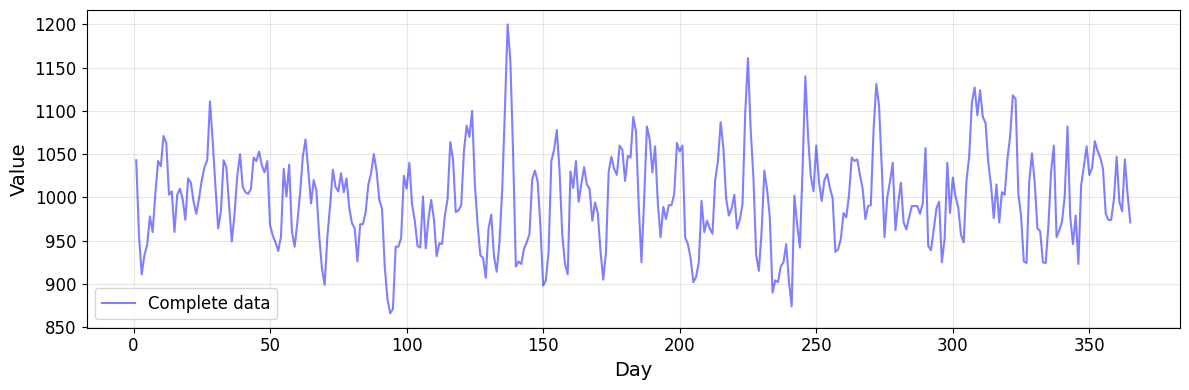

In [4]:
orders = df["ORDERS"].to_numpy()

plot_time_series(orders)

Before continuing, just have a look at the data and ask yourself how you would describe this time series. We will see later that MA models cannot handle all kinds of time series but make various assumptions.

**Side note:** The purpose of this dataset is not to gain real-world insights but just to have "some" time series as an example to introduce MA models. In fact, this dataset was synthetically generated to have certain characteristics but also to later assess the performance of MA models fitted on that data. We provide more details on the data generation after covering the basics of MA models.

---

## MA Models &mdash; The Basics

This section introduces the basic concepts behind Moving Average (MA) models. Following a brief recap of time series and Autoregressive (AR) models, we formally define the $\text{MA}(q)$ model and develop an intuitive understanding of how it represents a time series through current and past random shocks. We then discuss the main assumptions underlying MA models, including stationarity, white-noise shocks, and the finite influence of shocks. Finally, we introduce the important concept of invertibility, which ensures a unique and stable MA representation and establishes a useful connection between MA and AR models.

### Quick Recap: Time Series & AR Models

Before introducing $\text{MA}(q)$ models, it is useful to briefly revisit the basic concepts of time series and $\text{AR}(p)$ models. AR models provide a comparatively intuitive starting point because they explain the current value of a time series directly through its previous observed values. MA models build on many of the same time-series concepts but introduce an additional challenge by modeling the current value using **unobserved past shocks** instead. Keeping the familiar AR framework in mind therefore provides a useful reference point for understanding both the similarities and the important differences that make MA models somewhat more complex.

#### Time Series

A time series is a sequence of observations recorded in chronological order, typically at regular intervals such as hourly, daily, or monthly. Unlike ordinary datasets, the ordering of observations matters because values at one point in time may depend on previous observations, creating **temporal dependencies** that can be analyzed and used for forecasting. In its most fundamental form, a time series $\mathcal{S}$ is mathematically most commonly defined as an **ordered sequence of observations indexed by time**, which we can express as:

$$\large
\mathcal{S} = \{x_t\}_{t \in \mathcal{T}},
$$

where $\mathcal{T}$ is the time index set (e.g., ${1,\ldots,T}$, but also $\mathbb{N}$ or $\mathbb{R})$; and $x_t \in \mathcal{X}$ is the observation at time $t$. For a finite discrete time series, which we typically work with in practice, we can express a times series as tuple of observations:

$$\large
\mathbf{x} = (x_1, x_2, \ldots, x_T)
$$

In the context of our example dataset, $x_t$ represents the observed electricity load on day $t$. Since we have the daily observations for a whole year, our time series has the values $(x_1, x_2, \ldots, x_{365})$.

Although more advanced definitions of time series exists &mdash; for example, to explicitly model the time stamps, multiple observations per time stamp, or observations from multiple processes &mdash; basic AR model expects a simple list of individual observations as input, this matching the simple definition above.

**Important:** The notation used for time series observations varies across the literature. Classical textbooks on statistics, econometrics, and state-space models often denote observations by $y_t$. In contrast, contemporary machine learning literature commonly uses $x_t$ to represent observed data, particularly when time series are treated as sequences of input vectors. These choices are purely notational and have no mathematical implications, provided they are used consistently. Throughout this notebook, we adopt the notation $x_t$ for observations, as it aligns with modern machine learning conventions and naturally extends to multivariate time series.

#### Autoregressive (AR) Models

An autoregressive (AR) model is a **linear model** that assumes the current value of a time series can be expressed as a linear combination of its previous values, plus a random shock (or innovations). In other words, each previous observation contributes proportionally to the current observation through a corresponding coefficient. The model is called *autoregressive* because it uses the time series' own past observations as predictors of its future values.

A basic AR model is fully specified by its **lag order**, denoted by (p), which determines how many previous observations are used to predict the current one. An AR model with lag order (p) is written as $\text{AR}(p)$. For example, an $\text{AR}(p)$ model uses only the immediately preceding observation, whereas an $\text{AR}(p)$ model uses the three most recent observations. Thus, the lag order controls the amount of historical information, or "memory," that the model incorporates when making predictions.

Mathematically, an $\text{AR}(p)$ model is therefore defined as follows:

$$
\begin{align}
\large x_t\ &\large= c + \phi_1 x_{t-1} + \phi_2 x_{t-1} + \cdots + \phi_p x_{t-p} + \varepsilon_t \\[0.75em]
&\large= c + \sum_{i=1}^{p} \phi_i x_{t-i} + \varepsilon_t
\end{align}
$$

where

* $x_i$ is the observation at time step $t$
* $\phi_t$ is the coefficient or weight of observation $x_t$
* $\varepsilon_t$ is the shock or innovation; it captures the new information entering the time series that could not have been predicted from the past observations
* $c$ is a constant to allow for the process to have a non-zero mean

There are various approaches for estimating the parameters of an AR model, that is, for finding suitable values for the intercept $c$ and the coefficients $\phi_1$, $\phi_2$, ..., $\phi_p$. A particularly common approach is **Ordinary Least Squares (OLS)**, owing to the close similarity between an AR model and standard Linear Regression. In an $\text{AR}(p)$ model, the current observation $x_t$ is regressed on its $p$ previous values $x_{t-1}$, $x_{t-2}$, ..., $x_{t-p}$. The key difference from the standard Linear Regression setting is therefore that the features are not independent observations or predictors, but **dependent lagged values of the same time series**.

This structure is also what makes AR models comparatively straightforward to estimate and interpret: the prediction of $x_t$ is based entirely on previous, **directly observable values** of the time series. Once these lagged observations are available, estimating the AR coefficients closely resembles an ordinary regression problem. As we will now discuss in more detail, this convenient property no longer holds for MA models. There, the current observation depends on previous error terms (i.e., the shocks or innovations), which &mdash; unlike past observations of the time series &mdash; are not directly observable and therefore introduce an additional estimation challenge.

### Model Definition

An Moving Average (MA) model takes a different perspective from an AR model. Instead of explaining the current value of a time series using its **previous observed values**, an MA model explains it using **previous random shocks or prediction errors**. Intuitively, imagine that a time series is continuously exposed to unexpected events such as a sudden increase in demand, an unusually warm day, or an unexpected market movement. An MA model assumes that such shocks can influence the time series not only when they occur, but also for a limited number of subsequent periods. Thus, while an AR model asks *"How do past values (i.e., observations) affect the current value?"*, an MA model asks *"How do past unexpected shocks affect the current value?"*

Mathematically, an $\text{MA}(q)$ model is written as:

$$
\begin{align}
\large x_t\ &\large= \mu + \varepsilon_t + \theta_1\varepsilon_{t-1} + \theta_2\varepsilon_{t-2} + \cdots + \theta_q\varepsilon_{t-q}\\[1em]
&\large = \mu + \varepsilon_t + \sum_{i=1}^{q}\theta_i\varepsilon_{t-i}
\end{align}
$$

where 

* $\varepsilon_t$ is the current random shock (typically assumed to be white noise; see core assumptions)
* $\theta_i$ is the coefficient or weight of observation $\varepsilon_i$
* $\mu$ is the mean of the process

The order $q$ specifies how many previous shocks have an effect. For example, in an MA(1) model:

$$\large
x_t = \mu + \varepsilon_t + \theta_1\varepsilon_{t-1}.
$$

A crucial difference from AR models is that the $\varepsilon_t$'s are **not directly observable**. We observe the $x_t$'s, but not the underlying shocks that generated them. This makes estimating MA models less straightforward than simply applying OLS to lagged observations.

To look a bit more closely at the model definition, let's start with mean $\mu$ and its meaning. The intuition behind $\mu$ is that it represents the **baseline or long-run level of the time series**. The MA model treats observations as fluctuations around this level, where those fluctuations are caused by current and recent random shocks. For example, if the shocks have mean zero, i.e., $E[\varepsilon_t]=0$, then taking expectations gives $E[x_t] = \mu$. So $\mu$ tells us where the series would be centered in the absence of systematic shocks. The $\varepsilon$-terms then describe temporary deviations around that level.

For example, suppose daily demand follows an $\text{MA}(1)$ process with $\mu=100$:

$$\large
x_t = 100+\varepsilon_t+0.6\varepsilon_{t-1}.
$$

Here, $100$ units is the typical or long-run demand level. If yesterday there was an unexpectedly large positive shock to demand, some of that effect persists into today through $0.6\varepsilon_{t-1}$. After the shock has *"worked its way through the model"*, the series returns to fluctuating around $100$. To better understand this let's consider now an $\text{MA}(3)$ model:

$$\large
x_t = \mu + \varepsilon_t + \theta_1\varepsilon_{t-1} + \theta_2\varepsilon_{t-2} + \theta_3\varepsilon_{t-3}
$$

Suppose a particular shock (\varepsilon_t) occurs at time (t). We can track **that same shock** through subsequent observations:

* At time $t$, it affects $x_t$ directly with coefficient $1$
* At time $t+1$, it appears as $\theta_1\varepsilon_t$
* At time $t+2$, it appears as $\theta_2\varepsilon_t$
* At time $t+3$, it appears as $\theta_3\varepsilon_t$
* At time $t+4$ and beyond, $\varepsilon_t$ no longer appears; its effect is completely gone.

For a concrete example, assume the following instance of a $\text{MA}(3)$ model:

$$\large
x_t = 100 + \varepsilon_t + 0.5\varepsilon_{t-1} + 0.3\varepsilon_{t-2} + 0.1\varepsilon_{t-3}
$$

and at time $t$ there is a positive shock of $\varepsilon_t=10$. Ignoring all other shocks, this particular shock contributes to the following time steps &mdash; naturally starting with $x_t$ &mdash; as follows:

$$\large
\begin{array}{c|c}
\text{Observation} & \text{Effect of shock }\varepsilon_t=10\\
\hline
x_t & 10\\
x_{t+1} & 0.5(10)=5\\
x_{t+2} & 0.3(10)=3\\
x_{t+3} & 0.1(10)=1\\
x_{t+4} & 0\\
x_{t+5} & 0
\end{array}
$$

So *"working its way through"* means that the shock propagates through a finite number of future observations before disappearing completely. In an $\text{MA(3)}$ model, a shock occurring at time $t$ affects $x_t$ and the next three observations, ($x_{t+1}$, $x_{t+2}$ ,$ x_{t+3}$), but has no effect on $x_{t+4}$ or later observations.

**Side note:** In the previous example, the values for $\theta_1$, $\theta_2$, and $\theta_3$ are all positive, all less than $1$, and gradually decrease. This makes the idea of a shock gradually working its way through an $\text{MA}(3)$ model easy to see. However, this is not a requirement. While in many fitted models you will encounter coefficients with moderate magnitudes, say roughly $0.1-0.8$ (or their negative counterparts!), more often than very large coefficients, this is a practical observation and not a mathematical rule. In practical time series, the coefficients $\theta_i$ depend heavily on the process, sampling frequency, scaling, and model specification. For example, negative values are quite common and simply mean that a shock has an effect in the opposite direction at that lag. For example, $\theta_1=-0.7$ means that a positive shock today tends to contribute negatively to tomorrow's observation.

In short, in an $\text{MA}(q)$ model, a particular shock has a **finite lifespan**: after $q$ time steps, that shock no longer directly affects the series. Throughout this process, $\mu$ remains the center around which the series fluctuates. Note that this is in contrast to an $\text{AR}(p)$ model, where a a shock $\varepsilon_t$ can affect $x_t$, which affects $x_{t+1}$, which affects $x_{t+2}$ and so forth. This, at least in principle, shocks can have an infinite lifespan (but diminishing!) in an $\text{AR}(p)$ model. When it comes to the practical application, there is no one model that is better than the other, or one is more realistic than the other. They rather represent different kinds of dynamics:

* An $\text{MA}(q)$ model makes sense when shocks themselves have relatively short-lived direct consequences. For example, a temporary supply disruption might affect production for a few periods and then disappear entirely.

* An $\text{AR}(p)$ models makes sense when the variable exhibits persistence. For example, if unemployment rises substantially this month, unemployment next month is also likely to remain elevated. The effect does not suddenly vanish after exactly three months; instead, the system may gradually return toward its normal level.

Of course, many real-world time series, exhibit both mechanism, motivating the combination of $\text{AR}(p)$ and $\text{MA}(q)$ to more advanced $\text{ARMA}(p,q)$ model &mdahs; but which are beyond the scope of this notebook; here the focus is on $\text{MA}(q)$ model.

### Core Assumptions

The $\text{MA}(q)$ model has a relatively simple definition: the current observation is expressed as a linear combination of the current and previous $q$ random shocks; just to show the notation again:

$$\large
x_t = \mu + \varepsilon_t + \theta_1\varepsilon_{t-1} + \theta_2\varepsilon_{t-2} + \cdots + \theta_q\varepsilon_{t-q}
$$

This simplicity, however, comes with several assumptions about the underlying time series and the process generating it. In particular, a standard $\text{MA}(q)$ process is stationary, with a constant mean and variance over time, and assumes that the underlying shocks are unpredictable, uncorrelated across time, and have constant variance. Moreover, the influence of each shock is assumed to last for only a finite number of periods. These assumptions make MA models mathematically convenient, but also determine the types of time-series dynamics they can represent. So let's look at the individual assumptions in a bit more detail.


**Linear and constant $\phi_i$.** The definition above clear shows that $\text{MA}(q)$ models are linear models, i.e., we assume a linear relationship between observation $x_t$ and the shocks $\varepsilon_{t}$, $\varepsilon_{t-1}$, $\varepsilon_{t-2}$, ..., $\varepsilon_{t-q}$. We also assume that this linear relationship is time-invariant, meaning that the same values for the coefficients $\theta_1$, $\theta_2$, ..., $\theta_q$ apply throughout the time series. As mentioned before, because of the finite lifespan of shocks, we make no assumptions regarding the magnitude of the coefficients $\theta_i$.


**Constant mean $\mu$**. We assume that the time series fluctuates a constant mean, i.e., the process has a fixed long-run level $E[\varepsilon_t] = \mu$. In simple terms, this means that the time series does not exhibit trends, structural breaks, or seasonality &mdash; any characteristic that implies that $E[\varepsilon_t]$ is not constant but changes over time.

**Shocks are white noise.** In an $\text{MA}(q)$ model, the shocks $\varepsilon_t$ are assumed to be white noise, meaning that they represent purely random and unpredictable new information entering the time series. Specifically, the shocks have a mean of zero, a constant variance, and are uncorrelated across time; or more formally:

$$\large
E[\varepsilon_t]=0,\qquad
\text{Var}(\varepsilon_t)=\sigma_\varepsilon^2,\qquad
\text{Cov}(\varepsilon_t,\varepsilon_{t-k})=0\quad(k\neq0).
$$

Intuitively, knowing previous shocks should therefore provide no information about the next shock. Any temporal dependence observed in the MA series arises not because the shocks themselves are correlated, but because the same shocks affect multiple consecutive observations through the coefficients $\theta_i$. Note that this notation does not necessarily say what distribution each $\varepsilon_t$ follows. The shocks could, in principle, follow many different distributions as long as the white-noise conditions hold. However, a stringer and very common assumption is **Gaussian white noise**:

$$\large
\varepsilon_t \overset{iid}{\sim} N(0,\sigma_\varepsilon^2).
$$

Here we explicitly assume that the shocks are independent and normally distributed. Because independence is stronger than merely being uncorrelated, Gaussian white noise is a more restrictive assumption than the basic definition of white noise. In short, $\text{MA}(q)$ do not require the shocks be sampled from a particular distribution, as long as $E[\varepsilon_t]=0$ and $\text{Var}(\varepsilon_t)=\sigma_\varepsilon^2$. The assumption of a normal distribution is not required but often made in practice.

The assumptions of a constant mean, constant variance, and a stable dependence structure over time together imply that we treat the underlying time series as **(weakly) stationary**. In other words, although individual observations may fluctuate considerably, the statistical properties governing these fluctuations do not systematically change over time. To illustrate this, The two plots below show a stationary (top) and nonstationary (bottom) time series. The nonstationary time series has a clear upward trend, meaning that the expected value of an observation is not constant. Furthermore, the amplitude of the nonstationary time series increases over time. This, in turn, means that the variance is also not constant.

<img src="images/plots/tsa/tsa-example-stationary-series.png" style="margin:auto;max-width:600px;width:100%" alt="Time Series Example - Stationary Series">
<img src="images/plots/tsa/tsa-example-nonstationary-series.png" style="margin:auto;max-width:600px;width:100%" alt="Time Series Example - Nonstationary Series">

The weak stationarity assumption is typically assessed through a combination of visual inspection and statistical tests. A time series plot can reveal obvious violations such as trends, seasonality, changes in variance, or structural breaks, all of which indicate non-stationarity (see the two example plots above). In addition, formal tests such as the **Augmented Dickey–Fuller (ADF)** test and the **KPSS** test are commonly used to assess stationarity from complementary perspectives: the ADF test has a null hypothesis of a unit root (non-stationarity), whereas the KPSS test assumes stationarity under the null. Since no single test is definitive, stationarity should be evaluated by combining graphical analysis with statistical testing.

**Finite horizon for the influence of shocks.** Each shock $\varepsilon_t$ is assumed to have a finite influence on the time series. Specifically, a shock occurring at time $t$ affects the current observation $x_t$ and at most the next $q$ observations, $x_{t+1}$, $x_{t+2}$, ..., $\ldots,x_{t+q}$. After that, its effect is exactly zero. Thus, an $\text{MA}(q)$ model assumes that unexpected events have a limited lifespan rather than influencing the series indefinitely.

**Sufficient Observations.** Like for $\text{AR}(p)$ models &mdash; and machine learning models in general &mdash; we similarly need enough observations to reliably estimate $\mu$ and the $q$ coefficients $\theta_i$ for an $\text{MA}(q)$ model. In fact, the estimation can be more demanding than for AR models, because the past shocks $\varepsilon_{t-i}$ are not directly observed but must effectively be inferred jointly with the model parameters, typically using maximum likelihood or related numerical methods. However, there is no universal minimum sample size beyond the mathematical requirement; "sufficient" means enough observations relative to the model complexity to obtain stable and reliable parameter estimates. For a short time series, a low-order MA model such as $\text{MA}(1)$ may be feasible, whereas estimating a high-order MA model would generally be difficult to justify.

**Regular Sampling.** Standard discrete-time $\text{MA}(q)$ models generally assume that the time series is regularly sampled, meaning consecutive observations correspond to equal time intervals. For example, if observations are daily, an $\text{MA}(3)$ describes the effects of shocks from one, two, and three days ago. With irregular sampling &mdash; say observations occur after 1 day, then 3 days, then 10 days &mdash; "one lag ago" no longer corresponds to a consistent amount of elapsed time. The standard MA coefficients therefore lose their usual interpretation. Such data generally need to be resampled to a regular frequency or handled using models designed for irregularly spaced time series.

### Common Assumption: Invertibility

Although not a core assumption, we commonly assume an $\text{MA}(q)$ model to be **invertible**. The basic intuition behind invertibility is that the model should provide a **unique** and meaningful explanation of the observed time series in terms of its underlying shocks. Without invertibility, different combinations of coefficients $\theta_i$ and unobserved shocks $\varepsilon_i$ can generate the same observable behavior, meaning that we cannot uniquely determine which model produced the data. By restricting the model to be invertible, we select a unique representation and ensure that the unobserved shocks can, in principle, be reconstructed from the current and past observations of the time series.

To get a basic intuition for this, let's consider a general $\text{MA}(1)$ model and show how it can explain the *same* time series but with *different* model parameters. Thus, we start with the model:

$$\large
x_t = \mu + \varepsilon_t + \theta_1\varepsilon_{t-1}
$$

And let's assume that $\varepsilon_t \overset{iid}{\sim} N(0,\sigma_\varepsilon^2)$, even though we do not strictly require a normal distribution. In any case, our $\text{MA}(1)$ is fully described by the mean $\mu$, lag-1 coefficient $\theta_1$, and variance $\sigma_\varepsilon^2$. We can now show that different values for these parameters may explain the same time series. For this, we need to look at the lag-1 autocorrelation $\rho(1)$, which describes how strongly observation $x_t$ is linearly related to the observation one time step earlier, $x_{t-1}$ &mdash; since we only have an $\text{MA}(1)$ model, we do not need to consider autocorrelation for larger lags.

Now, for our $\text{MA}(1)$ model, we derive $\rho(1)$ from the definition of autocorrelation:

$$\large
\rho(1) = \frac{\gamma(1)}{\gamma(0)}
$$

where, by definition:

$$\large
\gamma(1)=\text{Cov}(x_t,x_{t-1})\quad \text{and}\quad \gamma(0) = \text{Cov}(x_t,x_t) = \text{Var}(x_t)
$$

Let's first consider $\gamma(0)$. Since subtracting the constant mean $\mu$ does not affect the variance variance, we can write

$$\large
\text{Var}(x_t) = \text{Var}(\varepsilon_t + \theta_1\varepsilon_{t-1})
$$

Using the general rule regarding the sum of two random variables $A$ and $B$ stating that $\text{Var}(A+B)=\text{Var}(A)+\text{Var}(B)+2\text{Cov}(A,B)$, as well as the rule to move a constant factor $\alpha$ of a random variable $X$, i.e., $\text{Var}(\alpha X) = \alpha^2\text{Var}(X)$, we obtain:

$$\large
\gamma(0) = \text{Var}(\varepsilon_t) + \theta_1^2\text{Var}(\varepsilon_{t-1}) + 2\theta_1\text{Cov}(\varepsilon_t,\varepsilon_{t-1})
$$

Because the shocks are white noise, $\text{Cov}(\varepsilon_t,\varepsilon_{t-1})=0$, and both shocks have variance $\sigma_\varepsilon^2$, we get the final expression for $\gamma(0)$ as:

$$\large
\gamma(0) = \sigma_\varepsilon^2(1+\theta_1^2)
$$

Next, $\gamma(1)$. We already saw that $\gamma(1)=\text{Cov}(x_t,x_{t-1})$. Writing out both observations $x_t$ and $x_{t-1}$ gives us:

$$
\begin{align}
\large x_t\ &\large= \mu + \varepsilon_t+\theta_1\varepsilon_{t-1}\\[0.5em]
\large x_{t-1} &\large= \mu + \varepsilon_{t-1}+\theta_1\varepsilon_{t-2}
\end{align}
$$

Again, we can subtract the constant mean $\mu$ from both expression without changing the variances, allowing us to write:

$$\large
\gamma(1) = \text{Cov}\left(\varepsilon_t+\theta_1\varepsilon_{t-1}, \varepsilon_{t-1}+\theta_1\varepsilon_{t-2} \right)
$$

By applying similar rules for working with variances, we can expand this expression to:

$$
\begin{aligned}
\large \gamma(1)=\ &\large \text{Cov}(\varepsilon_t,\varepsilon_{t-1})\\[0.25em]
&\large\ + \theta_1\text{Cov}(\varepsilon_t,\varepsilon_{t-2})\\[0.25em]
&\large\ + \theta_1\text{Cov}(\varepsilon_{t-1},\varepsilon_{t-1})\\[0.25em]
&\large\ + \theta_1^2\text{Cov}(\varepsilon_{t-1},\varepsilon_{t-2})
\end{aligned}
$$

Now, because shocks at **different times** are uncorrelated, three of these four terms are zero. The only surviving term is the one involving the **same shock**, $\varepsilon_{t-1}$. Thus, the only term of interest simplifies to:

$$\large
\text{Cov}(\varepsilon_{t-1},\varepsilon_{t-1}) = \text{Var}(\varepsilon_{t-1}) = \sigma_\varepsilon^2
$$

Therefore, we now have:

$$\large
\gamma(1) = \theta_1\sigma_\varepsilon^2
$$

With $\gamma(0)$ and $\gamma(1)$, we now have the expression for the lag-1 correlation $\rho(1)$:

$$\large
\rho(1) = \frac{\gamma(1)}{\gamma(0)} = \frac{\theta_1\sigma_\varepsilon^2}{\sigma_\varepsilon^2(1+\theta_1^2)} = \frac{\theta_1}{1+\theta_1^2}
$$

Finally, we come to the interesting part. Consider the two possible values for the coefficient $\theta_1=0.5$ and $\theta_1=2$, and let's plug them each into the expression above:

$$\large
\rho(1) = \frac{0.5}{1+0.25} = 0.4\ ,\qquad \rho(1) = \frac{2}{1+4} = 0.4
$$

In other words, for both values of $\theta_1$ we get the same lag-1 autocorrelation which, remember, describes how strongly observation $x_t$ is linearly related to the observation one time step earlier, $x_{t-1}$. This issue generalizes because:

$$\large
\rho(1) = \frac{\theta_1}{1+\theta_1^2} = \frac{1/\theta_1}{1+(1/\theta_1)^2}
$$

If we also adjust the shock variance $\text{Var}(\varepsilon_t)$ appropriately, the two models can generate exactly the same second-order behavior &mdash; and, under Gaussian shocks, the same distribution for the observed time series. For example,

$$\large
x_t = \mu + \varepsilon_t+0.5\varepsilon_{t-1}, \quad \text{Var}(\varepsilon_t)=4
$$

and

$$\large
x_t = \mu + \varepsilon^\prime_t+2\varepsilon^\prime_{t-1}, \quad \text{Var}(\varepsilon^\prime_t)=1
$$

both have $\gamma(0)=5$ and $\gamma(1)=2$, and zero autocovariance thereafter; because we only consider an $\text{MA}(1)$. Overall, this means that **from observations of $x_t$, we cannot distinguish between these two $\text{MA}(1)$ representations**. Note that this issue is not limited to $\text{MA}(1)$ models but generalizes to $\text{MA}(q)$, only that the math to show it is more involved.

This is where invertibility becomes practically important. Invertibility resolves this by restricting the parameter space. For an $\text{MA}(1)$, we impose:

$$\large
|\theta_1|<1
$$

So when fitting the model, the estimation procedure is effectively told: Among observationally equivalent MA representations, only consider the invertible one. For our example above, it would therefore select $\theta_1=0.5$ rather than $\theta_1=2$. To better see why $|\theta_1|<1$ matters, let's go back to our $\text{MA}(1)$ model and rearrange it to get an expression to reconstruct $\varepsilon_t$:

$$\large
\varepsilon_t=(x_t-\mu)-\theta_1\varepsilon_{t-1}
$$

Of course, we can equally reconstruct $\varepsilon_{t-1}$ with:

$$\large
\varepsilon_{t-1}=(x_{t-1}-\mu)-\theta_1\varepsilon_{t-2}
$$

and so on for $\varepsilon_{t-2}$, $\varepsilon_{t-3}$, etc. Thus, repeatedly substituting shocks gives us:

$$\large
\varepsilon_t = (x_t-\mu) - \theta_1(x_{t-1}-\mu) + \theta_1^2(x_{t-2}-\mu) - \theta_!^3(x_{t-3}-\mu)+\cdots 
$$

For this expression to be stable, the coefficients $-\theta_1$, $\theta_1^2$, $-\theta_1^3$, ... must shrink toward zero. That happens when $|\theta|<1$, so $\theta_1 = 0.5$ yields and invertible MA representation. In contrast, for $\theta_1 = 2$, the coefficients become $-2$, $4$, $-16$, ..., i.e., they explode. We therefore cannot obtain a stable causal reconstruction of today's shock from current and past observations. Or vice versa, **invertibility means that the coefficients allow shocks to be stably recovered from the observed data**.

For an $\text{MA}(1)$ model, the invertibility condition is simply $|\theta_1|<1$; for an $\text{MA}(q)$ model, however, invertibility depends on the **combined effect of all coefficients $\theta_i$** rather than on each coefficient individually. Specifically, we form the MA polynomial $\Theta(z)=1+\theta_1z+\theta_2z^2+\cdots+\theta_qz^q$ and find the values of $z$ for which $\Theta(z)=0$. The $\text{MA}(q)$ model is invertible if **all roots of this polynomial lie outside the unit circle**, that is, if $|z_i|>1$ for every root. Thus, unlike the $\text{MA}(1)$ case, invertibility does not generally require every individual $|\theta_i|$ to be smaller than $1$; rather, it is the relationship among all coefficients, captured by the roots of the MA polynomial, that determines whether the model is invertible. However, we omit a deep dive into the math here since it does not change the core idea behind invertibility.

Invertibility reveals an important connection between MA and AR models: an invertible $\text{MA}(q)$ process can be rewritten as an $\text{AR}(\infty)$ process, i.e., as an autoregressive model involving potentially infinitely many past observations. The intuition is that invertibility allows the unobserved shocks in the MA representation to be reconstructed from the observed history of the time series. Substituting these reconstructed shocks back into the MA equation expresses the current observation entirely in terms of past observations, with coefficients that become progressively smaller as the lag increases. Thus, an MA model can be viewed from two complementary perspectives: as a process driven by a **finite number of past shocks**, or &mdash; when invertible &mdash; as a process whose current value depends on an **infinite but typically diminishing history of past observations**.

Practically, this connection means that **AR and MA models are less fundamentally different than their definitions might initially suggest**. An invertible MA process can often be approximated by a sufficiently high-order AR model because the coefficients on distant observations become increasingly small. It also explains why invertibility is so useful: although the MA model is formulated in terms of unobserved shocks, invertibility ensures that those shocks &mdash; and hence the dynamics of the model &mdash; can be expressed using the observed time series itself. The reverse relationship also holds under appropriate stationarity conditions: a stationary AR process can be represented as an $\text{MA}(\infty)$ process, highlighting the close duality between the two model classes.

---

## Fitting an MA Model

Compared with $\text{AR}(p)$ models, $\text{MA}(q)$ models are somewhat more difficult to fit. In an AR model, the predictors are lagged observations $x_{t-1}$, $x_{t-2}$, ..., $x_{t-p}$, which are **directly available** in the observed time series. This makes it possible to estimate the model using familiar regression techniques such as Ordinary Least Squares (OLS). In an MA model, by contrast, the explanatory terms are previous shocks $\varepsilon_{t-1}$, $\varepsilon_{t-2}$, ..., $\varepsilon_{t-q}$, which are **not directly observed**. The MA coefficients and the underlying shocks therefore have to be inferred jointly from the observed data.

Several approaches have been developed for this purpose, differing in computational complexity, statistical efficiency, and ease of interpretation; the table below outlines and compares the most common approaches.

| Approach                                | Basic idea                                                                                                                                            | Pros                                                                                                                                      | Cons                                                                                                                                                        |
| --------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Maximum Likelihood Estimation (MLE)** | Choose the MA parameters that make the observed time series most likely under the assumed model, typically using numerical optimization.              | Statistically efficient; widely used in practice; naturally extends to ARMA/ARIMA models; can impose invertibility.                       | Requires numerical optimization; more computationally demanding; exact likelihood often relies on a distributional assumption such as Gaussian shocks. |
| **Conditional Sum of Squares (CSS)**    | For candidate MA parameters, recursively estimate the unobserved shocks and choose the parameters that minimize the sum of their squared values.      | Relatively intuitive and computationally simpler; useful for obtaining initial estimates for MLE.                                         | Depends on how the initial unobserved shocks are handled; generally less efficient than exact MLE, especially for smaller samples.                          |
| **Moment / ACF-based methods**          | Choose the MA parameters so that the theoretical autocorrelations implied by the model approximately match the autocorrelations observed in the data. | Conceptually simple; directly connects the parameters to the dependence structure; useful for model identification and initial estimates. | Can be statistically inefficient; solving for the parameters may be nonlinear and can yield multiple solutions; less commonly used for final estimation.    |

**Side note:** Recall that the previously stated that if an $\text{MA}(q)$ model is invertible, it has an equivalent $\text{AR}(\infty)$ representation, so it can in principle be approximated by fitting an $\text{AR}(p)$ model with a sufficiently large lag order $p$. This is attractive because the AR approximation uses only observed lagged values and can therefore be estimated straightforwardly using OLS. However, the representation is exact only when $p\rightarrow\infty$; with a finite $p$, some approximation error remains, while choosing a very large $p$ requires estimating many parameters, consumes observations, and can increase estimation variance and overfitting. Consequently, high-order AR models are generally not the preferred method for obtaining the final MA parameter estimates when likelihood-based methods are available. They are, however, commonly used as an auxiliary tool—for example, to approximate the unobserved shocks or obtain initial estimates as part of more sophisticated MA estimation procedures.

Among the different approaches, **Maximum Likelihood Estimation (MLE)** is one of the most widely used standard methods. Rather than requiring the unobserved shocks to be available directly, MLE estimates the model parameters by finding the values that make the observed time series most likely under the assumed MA model. Its strong statistical properties and applicability to more general models such as ARMA and ARIMA make MLE particularly important in practice. For this reason, we will examine the basic idea and application of MLE for estimating MA models in more detail in the following.

### Maximum Likelihood Estimation (MLE)

The fundamental idea behind **Maximum Likelihood Estimation (MLE)** is to find the model parameters that make the data we actually observed **as likely as possible** under the assumed model. In other words, we consider different possible values for the unknown parameters, calculate how plausible the observed data would be for each choice, and select the parameter values that give the highest likelihood. For an $\text{MA}(q)$ model, this means searching for values of the MA coefficients and the shock variance that provide the most plausible explanation of the observed time series.

#### Model Definition & Statistical Assumptions

To see how this works, let's first have another look at the definition of an $\text{MA}(q)$ model:

$$\large
x_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \dots + \theta_q \varepsilon_{t-q}
$$

where:

* $\boldsymbol{\theta} = (\mu, \sigma^2, \theta_1, \theta_2, \dots, \theta_q)^\top$ is the vector of parameters to estimate
* $\varepsilon_t \overset{iid}{\sim} N(0,\sigma_\varepsilon^2)$ &mdash; that is, we assume Gaussian white noise to make the math concrete
* $\mathbf{x} = (x_1, x_2, \dots, x_n)^\top$ is the $n \times 1$ vector of observed data points (i.e., the time series)
* $t = 1, 2, \dots, T$ represents the time steps
  
MLE works by choosing all parameters of $\boldsymbol{\theta}$ that makes the time series $\mathbf{x}$ most likely (under the assumption the shocks $\varepsilon_i$ are Gaussian).

#### Construct Likelihood Function

In MLE, the step of constructing likelihood function addresses the question: *How likely is it to observe our time series $\mathbf{x}$ assuming it is generated by the $\text{MA}(q)$ process described by the model parameters in $\boldsymbol{\theta}$?* For our $\text{MA}(q)$ model, the likelihood $L$ is the joint density of the observed samples in the time series, viewed as function of the unknown parameters $\boldsymbol{\theta}$; mathematically we write this function as:

$$\large
L(\boldsymbol{\theta}) = f(x_1, x_2, \dots, x_T\mid \boldsymbol{\theta})
$$

Using the **definition of conditional probability** recursively, any joint density can be factored exactly using the probability chain rule:

$$\large
f(x_1, x_2, \dots, x_T\mid \boldsymbol{\theta}) = f(x_1 \mid \boldsymbol{\theta}) \cdot f(x_2 \mid x_1, \boldsymbol{\theta}) \cdot f(x_3 \mid x_1, x_2, \boldsymbol{\theta}) \cdots f(x_n \mid x_1, x_2, \dots, x_{n-1}, \boldsymbol{\theta})$$

Using product notation, this is written as:

$$\large
L(\boldsymbol{\theta}) = f(x_1 \mid \boldsymbol{\theta}) \prod_{t=2}^T f(x_t \mid x_1, \dots, x_{t-1}, \boldsymbol{\theta})
$$

Since products are inconvenient to optimize, so we usually work with the **log-likelihood**, which turn the product of densities into the sum of log densities:

$$
\begin{align}
\large\ell(\boldsymbol{\theta})\ &\large= \log{L(\boldsymbol{\theta})}\\[0.5em]
&\large= \log{f(x_1 \mid \boldsymbol{\theta})} + \sum_{t=2}^T \log{f(x_t \mid x_1, \dots, x_{t-1}, \boldsymbol{\theta})}
\end{align}
$$

The last step is then to estimate the best model parameters $\boldsymbol{\theta}$ by finding the parameter values that maximize the log-likelihood:

$$\large
\hat{\boldsymbol{\theta}}_{\text{MLE}} = \arg\max_{\boldsymbol{\theta}}\ell(\boldsymbol{\theta})
$$

While this is the basic MLE approach, to now actually fit a model, we need to define the density function $f(x_t \mid x_1, \dots, x_{t-1}, \boldsymbol{\theta})$. So let's do this for an $\text{MA}(1)$ model to keep the math sample; however, the same approach scales to general $\text{MA}(q)$ models. Moreover, we assume that the shocks are normally distributed. Thus, more formally, we have:

$$\large
x_t=\mu+\varepsilon_t+\theta_1\varepsilon_{t-1}, \qquad \varepsilon_t\overset{iid}{\sim}N(0,\sigma_\varepsilon^2)
$$

This poses the first main challenge: $x_t$ depends on **unobserved** shocks $\varepsilon_i$. However, given the model definition above we can reconstruct and therefore estimate the shocks be rearranging the expression; below shows the idea for the first three shocks:

$$
\begin{align}
\large \hat\varepsilon_1\ &\large = x_1-\mu-\theta_1\hat\varepsilon_0\\[0.5em]
\large \hat\varepsilon_2\ &\large = x_2-\mu-\theta_1\hat\varepsilon_1 \\[0.5em]
\large \hat\varepsilon_3\ &\large = x_3-\mu-\theta_1\hat\varepsilon_2
\end{align}
$$

We can generalize this to:

$$\large
\hat\varepsilon_t = x_t-\mu-\theta_1\hat\varepsilon_{t-1}
$$

Note that we write $\hat{\varepsilon}_t$ to express that we deal with an estimation here.

A second challenge is now the value of $\hat{\varepsilon}_0$ we need to start the recursion; see also the term $f(x_1 \mid \boldsymbol{\theta})$ in the expression for $L(\boldsymbol{\theta})$ above. If our observed series starts at $x_1$, the $\text{MA}(1)$ equation $x_1=\mu+\varepsilon_1+\theta_1\varepsilon_0$ involves the pre-sample shock $\varepsilon_0$, which we never observed. There are two common approaches to address this issue. **Conditional Maximum Likelihood Estimation (Conditional MLE)** resolves the problem by conditioning on a fixed initial value, typically setting $\varepsilon_0=0$, its expected value. This allows all subsequent shocks to be calculated recursively and leads to a relatively simple likelihood function. For an invertible MA model, the influence of this initialization diminishes over time, making the approximation increasingly unimportant for longer time series.

**Exact Maximum Likelihood Estimation (Exact MLE)**, in contrast, does not simply fix the unknown initial shock. Instead, it accounts explicitly for the uncertainty associated with the unobserved pre-sample shocks when constructing the likelihood, for example through the joint Gaussian distribution or a state-space representation. This provides a more exact treatment of the beginning of the time series and can be particularly relevant for shorter samples, but it is mathematically and computationally more involved. For this reason, Conditional MLE provides a particularly useful and intuitive way to understand the basic mechanics of fitting an MA model. This is why we stick with the Conditional MLE with $\varepsilon_0=0$ in the following.

We can now rearrange the expression for $x_t$ to make it explicit it is a combination of a conditional mean &mdash; condition on the previous observation based on the recursive estimation for $\varepsilon_i$ (see above) &mdash; and the new random shock $\varepsilon_t$:

$$\large
x_t = \underbrace{\mu+\theta_1\hat\varepsilon_{t-1}}_{\text{conditional mean}} + \underbrace{\varepsilon_t}_{\text{new random shock}}
$$

Since $\varepsilon_t{\sim}N(0,\sigma_\varepsilon^2)$, we know that $x_t$ is also sampled from a Gaussian distribution with mean $\mu+\theta_1\hat\varepsilon_{t-1}$ and variance $\sigma_\varepsilon^2$, but again, conditioned on the previous iteration and assuming $\varepsilon_0=0$. Thus, we can write:

$$\large
x_t \mid x_1,\ldots,x_{t-1},\varepsilon_0\!=\!0\ \sim N\left(\mu+\theta_1\hat\varepsilon_{t-1}, \sigma_\varepsilon^2 \right)
$$

With the definition of the Gaussian distribution, we can write the conditional density contribution of observation $x_t$ as:

$$\large
f(x_t\mid x_1,\ldots,x_{t-1}) = \frac{1}{\sqrt{2\pi\sigma_\varepsilon^2}} \exp\left[ -\frac{ \left(x_t-\mu-\theta_1\hat\varepsilon_{t-1}\right)^2}{2\sigma_\varepsilon^2}\right]
$$

Recall that we have $\hat\varepsilon_t = x_t-\mu-\theta_1\hat\varepsilon_{t-1}$, meaning that the expression simplfies to:

$$\large
f(x_t\mid x_1,\ldots,x_{t-1}) = \frac{1}{\sqrt{2\pi\sigma_\varepsilon^2}}\exp\left(-\frac{\hat\varepsilon_t^2}{2\sigma_\varepsilon^2}\right)
$$

We can now take this expression for the conditional density function to get our final expression for $\ell(\boldsymbol{\theta})$. In fact, since we perform Conditional MLE with $\varepsilon_0=0$, we no longer need to treat the first function $f(x_1 \mid \boldsymbol{\theta})$ individually by can incorporate it in the sum &mdash; notice how the start index under the sum changes from $t=2$ to $t=1$:

$$
\begin{align}
\large\ell(\boldsymbol{\theta}\mid \varepsilon_0\!=\!0)\ &\large= \sum_{t=1}^T \log{f(x_t \mid x_1, \dots, x_{t-1}, \boldsymbol{\theta})}\\[0.5em]
&\large = \sum_{t=1}^T \log{\left[ \frac{1}{\sqrt{2\pi\sigma_\varepsilon^2}}\exp\left(-\frac{\hat\varepsilon_t^2}{2\sigma_\varepsilon^2}\right) \right]}
\end{align}
$$

All that is left for the step of constructing the (conditional) likelihood is to simplify the expression which helps with the next step of maximizing this function. The following transformation relies on basic logarithm rules and working with sums.

$$
\begin{align}
\large\ell(\boldsymbol{\theta}\mid \varepsilon_0\!=\!0)\ &\large= \sum_{t=1}^T \log{\left[ \frac{1}{\sqrt{2\pi\sigma_\varepsilon^2}}\exp\left(-\frac{\hat\varepsilon_t^2}{2\sigma_\varepsilon^2}\right) \right]}\\[0.5em]
&\large= \sum_{t=1}^T \log{ \frac{1}{\sqrt{2\pi\sigma_\varepsilon^2}}} + \sum_{t=1}^T \log{ \left[ \exp\left(-\frac{\hat\varepsilon_t^2}{2\sigma_\varepsilon^2}\right) \right] }\\[0.5em]
&\large= \sum_{t=1}^T \log{ \left[ \left(2\pi\sigma_\varepsilon^2\right)^{-1/2}\right]} - \frac{1}{2\sigma_\varepsilon^2} \sum_{t=1}^T \hat\varepsilon_t^2\\[0.5em]
&\large= -\frac{1}{2}\sum_{t=1}^T \log{ \left(2\pi\sigma_\varepsilon^2\right)} - \frac{1}{2\sigma_\varepsilon^2} \sum_{t=1}^T \hat\varepsilon_t^2\\[0.5em]
&\large= -\frac{1}{2}\sum_{t=1}^T \log{ \left(2\pi\right)} -\frac{1}{2}\sum_{t=1}^T \log{ \left(\sigma_\varepsilon^2\right)} - \frac{1}{2\sigma_\varepsilon^2} \sum_{t=1}^T \hat\varepsilon_t^2\\[0.5em]
&\large= -\frac{T}{2}\log{ \left(2\pi\right)} -\frac{T}{2}\log{ \left(\sigma_\varepsilon^2\right)} - \frac{1}{2\sigma_\varepsilon^2} \sum_{t=1}^T \hat\varepsilon_t^2\\[0.5em]
\end{align}
$$

To summarize, our final conditional likelihood for our $\text{MA}(1)$ model is:

$$\large
\boxed{
\large\ell(\boldsymbol{\theta}\mid \varepsilon_0\!=\!0) = -\frac{T}{2}\log{ \left(2\pi\right)} -\frac{T}{2}\log{ \left(\sigma_\varepsilon^2\right)} - \frac{1}{2\sigma_\varepsilon^2} \sum_{t=1}^T \hat\varepsilon_t^2}
$$

#### Maximizing the Likelihood

Now that wit have the likelihood, we now need to find all values for the model parameters that maximize that likelihood, i.e.:

$$\large
\hat{\boldsymbol{\theta}}_{\text{MLE}} = \arg\max_{\boldsymbol{\theta}}\ell(\boldsymbol{\theta})
$$

Note that we still consider the conditional likelihood with $\varepsilon_0=0$; we only write $\ell(\boldsymbol{\theta})$ to ease presentation. Let's also rewrite this expression to make it explicitly, which parameters of our $\text{MA}(1)$ model we need to optimize &mdash; remember that $\boldsymbol{\theta}$ is a vector holding all model parameters:

$$\large
(\hat\mu, \hat\theta_1, \hat\sigma_\varepsilon^2) = \arg\max_{\mu, \theta_1, \sigma_\varepsilon^2}\ell(\mu, \theta_1, \sigma_\varepsilon^2)
$$

In principle, maximizing a likelihood function requires taking the derivative with respect to **each unknown parameter**, setting these derivatives equal to zero, and solving for the parameter values that maximize the likelihood. For an MA(1) model, however, the implied shocks depend recursively on (\mu) and (\theta_1), which makes the corresponding first-order conditions nonlinear and prevents a simple closed-form solution. A convenient approach is therefore to proceed in two steps:

* First, we maximize the likelihood with respect to the shock variance $\sigma_\varepsilon^2$, while keeping $\mu$ and $\theta_1$ fixed; this yields a simple analytical solution for $\hat{\sigma}_\varepsilon^2$.
* We then substitute this solution back into the likelihood to obtain a simplified **profile likelihood**, which only depends on $\mu$ and $\theta_1$; these remaining parameters can then be estimated using numerical optimization.

Let's therefore start with maximizing the likelihood function with respect to $\sigma_\varepsilon^2$. To this end, we keep $\mu$ and $\theta_1$ fixed and differentiate with respect to $\sigma_\varepsilon^2$:

$$\large
\frac{\partial \ell}{\partial \sigma_\varepsilon^2} = -\frac{T}{2\sigma_\varepsilon^2} + \frac{1}{2(\sigma_\varepsilon^2)^2} \sum_{t=1}^{T}\hat\varepsilon_t^2
$$

To find the the value for $\sigma_\varepsilon^2$ that maximizes this function, we need to set it to zero:

$$\large
-\frac{T}{2\sigma_\varepsilon^2} + \frac{1}{2(\sigma_\varepsilon^2)^2} \sum_{t=1}^{T}\hat\varepsilon_t^2 =0
$$

We can simplify this expression by multiplying both sides by $2(\sigma_\varepsilon^2)^2$ &mdash; the right side of the equation naturally remains $0$:

$$\large
-T\sigma_\varepsilon^2 + \sum_{t=1}^{T}\hat\varepsilon_t^2 = 0
$$

Thus, solving for $\sigma_\varepsilon^2$, we get:

$$\large
\hat\sigma_\varepsilon^2 = \frac{1}{T}\sum_{t=1}^{T}\hat\varepsilon_t^2
$$

Note that we strictly speaking only get an estimate (hence, $\hat\sigma_\varepsilon^2$) because we rely on the estimates $\hat{\varepsilon}_t$ for the shocks. Thus, for any given $\mu$ and $\theta_1$, we can now find the best estimate $\hat\sigma_\varepsilon^2$ that maximizes the likelihood functions &mdash; do not forget the estimates shocks are recursively defined based on $\mu$ and $\theta_1$, i.e.: $\hat\varepsilon_t = x_t-\mu-\theta_1\hat\varepsilon_{t-1}$.

To substitute this information back into the likelihood function to simplify it, let's define the residual sum of squares as function $S$ that depends on $\mu$ and $\theta_1$:

$$\large
S(\mu,\theta_1) = \sum_{t=1}^{T}\hat\varepsilon_t^2
$$

With this, we can express $\hat\sigma_\varepsilon^2$ as:

$$\large
\hat\sigma_\varepsilon^2 = \frac{S(\mu,\theta_1)}{T}
$$

Using this expression that tells us the best estimate for $\hat\sigma_\varepsilon^2$ for a given $\mu$ and $\theta_1$, we can now get the **profile log-likelihood** $\ell_p$. This is a simplified log-likelihood we obtain by analytically eliminating one or more parameters that are easy to solve for &mdash; in our case here, the estimated shock variance of our $\text{MA}(1)$ model. To to this, we substitute the expression for $\hat\sigma_\varepsilon^2$ we have just derived back into the original log-likelihood; not that this new log-likelihood $\ell_p$ is no longer a function of $\hat\sigma_\varepsilon^2$, but only of $\mu$ and $\theta_1$:

$$
\begin{align}
\large\ell_p(\mu, \theta_1\mid \varepsilon_0\!=\!0)\ &\large= -\frac{T}{2}\log{ \left(2\pi\right)} -\frac{T}{2}\log{ \left(\frac{S(\mu,\theta_1)}{T}\right)} - \frac{1}{2\left(\frac{S(\mu,\theta_1)}{T}\right)} S(\mu,\theta_1) \\[1em]
&\large= -\frac{T}{2}\log{ \left(2\pi\right)} -\frac{T}{2}\log{ \left(\frac{S(\mu,\theta_1)}{T}\right)} - \frac{T}{2}
\end{align}
$$

Thus, instead of numerically optimizing over three parameters ($\mu$, $\theta_1$, $\sigma_\varepsilon^2$), we only need to optimize over ($\mu$, $\theta_1$).

When it comes to maximizing $\ell_p$, notice that the first term and the last term do not depend on $\mu$ and $\theta_1$, and we can therefore treat them as constants; we can also ignore the constant factors of the term in the middle as they do not affect the optimization. This means, we only have the term $-\log{S(\mu, \theta_1)}$ left. However, since the logarithm is monotonically increasing, and considering the negative ($-$) sign, maximizing $\ell_p$ is equivalent to minimizing:

$$\large
S(\mu, \theta_1)\ , \quad \text{with}\ S(\mu,\theta_1) = \sum_{t=1}^{T}\hat\varepsilon_t^2
$$

So the Conditional MLE and assuming a Gaussian distributions of the shocks reduces to:

$$\large
\boxed{
(\hat\mu,\hat\theta_1) = \arg\min_{\mu,\theta_1} \sum_{t=1}^{T}\hat\varepsilon_t^2
}
$$

Recall that this optimization criterion is typically subject to the invertibility restriction, which in case of a $\text{MA}(1)$ model is $|\theta_1|<1$.

#### Numerical Optimization

So far, we know *what* we need to optimize but not yet *how*. Recall that shock estimates themselves depend recursively on $\mu$ and $\theta_1$:

$$
\begin{align}
\large \hat\varepsilon_1\ &\large = x_1-\mu-\theta_1\hat\varepsilon_0\\[0.5em]
\large \hat\varepsilon_2\ &\large = x_2-\mu-\theta_1\hat\varepsilon_1 \\[0.5em]
\large \hat\varepsilon_3\ &\large = x_3-\mu-\theta_1\hat\varepsilon_2 \\[0.5em]
\large...\ &\large =\ ... \\
\end{align}
$$

This means that our function $S(\mu,\theta_1) = \hat\varepsilon_1^2 + \hat\varepsilon_2^2 +\cdots+ \hat\varepsilon_T^2$ is a nonlinear function of $\theta_1$. Unlike Ordinary Least Squares (OLS) for an AR model, we generally cannot simply solve a linear system to obtain $\hat\theta_1$. We therefore need to search numerically for $\mu$ and $\theta_1$ that minimize $S(\mu,\theta_1)$. The general process works as follows

1. Choose starting value, say:

$$
\large\mu^{(1)},\ \large\theta_1^{(0)}
$$

2. For all $1 \leq t \leq T$, recursively compute: 

$$
\large\hat\varepsilon_t = x_t - \mu^{(0)} - \theta_1^{(0)}\hat\varepsilon_{t-1}
$$

3. Compute $S(\mu^{(0)}, \theta_1^{(0)})$ as: 

$$\large 
S(\mu^{(0)}, \theta_1^{(0)}) = \sum_{t=1}^{T}\hat\varepsilon_t^2
$$

4. Update the values for $\mu$ and $\theta$ such that id reduces $S$ and therefore increases the log-likelihood. When using a gradient-based method, the general update rules is:

$$
\large
\begin{bmatrix}
\mu^{(k+1)}\\
\theta_1^{(k+1)}
\end{bmatrix} =
\begin{bmatrix}
\mu^{(k)}\\
\theta_1^{(k)}
\end{bmatrix}
\eta_k \nabla S(\mu^{(k)},\theta^{(k)})
$$

<div style="margin-left: 30px;">
where $\nabla S$ contains the partial derivatives with respect to $\mu$ and $\theta_1$, and $\eta_k$ is the learning rate; more sophisticated optimizers such as Newton, BFGS, or L-BFGS use curvature information to choose better update directions.
</div>

5. Recomputing $S$: The important practical point is that every time $\mu$ or $\theta$ changes, the entire sequence of implied shocks changes as well, so $S(\mu,\theta)$ must be recomputed recursively. The optimizer repeats this process until the parameter changes or the improvement in $S$ becomes negligible. For an invertible $\text{MA}(1)$, the search is typically constrained to $|\theta_1|<1$. In short, if changes in $S$ become negligible, we stop; otherwise iteratively repeat Steps 2-5.

Once this iterative procedure stops, we have our final estimates are $\hat\mu$ and $\hat\theta_1$. With these two values we can the also compute the shock estimate $\hat\sigma_\varepsilon^2$ using the known expression:

$$\large
\hat\sigma_\varepsilon^2 = \frac{1}{T}\sum_{t=1}^{T}\hat\varepsilon_t^2
$$

To eventually implement the algorithm, the last puzzle piece we need is $\nabla S$ containing the partial derivatives with respect to $\mu$ and $\theta_1$. Because each $\hat\varepsilon_t$ depends on $\mu$ and $\theta_1$, we apply the chain rule:

$$\large
\frac{\partial S}{\partial \mu} = 2\sum_{t=1}^T \hat\varepsilon_t \frac{\partial \hat\varepsilon_t}{\partial \mu} \qquad \text{and} \qquad \frac{\partial S}{\partial \theta_1} = 2\sum_{t=1}^T \hat\varepsilon_t \frac{\partial \hat\varepsilon_t}{\partial \theta_1}
$$

The challenge is once again that the shock estimates themselves depend recursively on $\mu$ and $\theta_1$. This now also reflects in the computation of the partial derivatives. For $\mu$, we start from $\hat\varepsilon_t = x_t-\mu-\theta_1\hat\varepsilon_{t-1}$. Differentiating with respect to $\mu$ gives is:

$$\large
\frac{\partial\hat\varepsilon_t}{\partial\mu} = -1 -\theta_1 \frac{\partial\hat\varepsilon_{t-1}}{\partial\mu}
$$

Since we assume $\varepsilon_0 = 0$, we start the recursion with $\large\frac{\partial \hat\varepsilon_0}{\partial\mu}\normalsize = 0$. Thus, we can continue the recursion as follows:

$$
\begin{align}
\large \frac{\partial \hat\varepsilon_1}{\partial\mu}\ &\large = -1\\[0.5em]
\large \frac{\partial \hat\varepsilon_2}{\partial\mu}\ &\large = -1 + \theta_1\\[0.5em]
\large \frac{\partial \hat\varepsilon_3}{\partial\mu}\ &\large = -1 + \theta_1 - \theta_1^2\\[0.5em]
\large \frac{\partial \hat\varepsilon_4}{\partial\mu}\ &\large = -1 + \theta_1 - \theta_1^2 + \theta_1^3\\[0.5em]
\large ...\ &\large =\ ...\\
\end{align}
$$

For $\theta_1$, we differentiate $\hat\varepsilon_t = x_t-\mu-\theta_1\hat\varepsilon_{t-1}$ using the product rule to get:

$$\large
\frac{\partial\hat\varepsilon_t}{\partial\theta_1} = -\hat\varepsilon_{t-1} -\theta_1\frac{\partial\hat\varepsilon_{t-1}}{\partial\theta_1}
$$

Again, starting with $\large\frac{\partial \hat\varepsilon_0}{\partial\theta_1}\normalsize = 0$, we can start the recursive computation:

$$
\begin{align}
\large \frac{\partial \hat\varepsilon_1}{\partial\theta_1}\ &\large = 0\\[0.5em]
\large \frac{\partial \hat\varepsilon_2}{\partial\theta_1}\ &\large = -\hat\varepsilon_1\\[0.5em]
\large \frac{\partial \hat\varepsilon_3}{\partial\theta_1}\ &\large = -\hat\varepsilon_2 + \theta_1\hat\varepsilon_1\\[0.5em]
\large \frac{\partial \hat\varepsilon_4}{\partial\theta_1}\ &\large = -\hat\varepsilon_3 + \theta_1\hat\varepsilon_2 - \theta_1^2\hat\varepsilon_1\\[0.5em]
\large ...\ &\large =\ ...\\
\end{align}
$$

This recursive structure is exactly why solving $\partial S/\partial\mu=0$ and $\partial S/\partial\theta=0$ does not lead to a convenient closed-form estimator. Numerical optimization uses these gradients to iteratively update $\mu$ and $\theta$.

#### Beyond $\text{MA}(1)$ Models

All the steps we performed so far assumed an $\text{MA}(1)$ to keep the expressions as simple as possible. However, this core approach generalizes to arbitrary $\text{MA}(q)$ models:

$$\large
x_t=\mu+\varepsilon_t+\theta_1\varepsilon_{t-1}+\cdots+\theta_q\varepsilon_{t-q}
$$

Without showing all the steps again, the objective function $S$ is still just the sum of squared shock estimates:

$$\large
S(\mu,\theta_1,\ldots,\theta_q) = \sum_{t=1}^{T} \hat\varepsilon_t^2
$$

The only difference is that now each $\hat\varepsilon_t$ depends on $q$ previous shocks and on all $q$ MA coefficients. So as $q$ increases, $S$ becomes a higher-dimensional and more complicated nonlinear function. For example, for an $\text{MA}(3)$ model, we get:

$$\large
S(\mu,\theta_1,\theta_2,\theta_3) = \sum_{t=1}^{T} \left( x_t-\mu -\theta_1\hat\varepsilon_{t-1} -\theta_2\hat\varepsilon_{t-2} -\theta_3\hat\varepsilon_{t-3} \right)^2
$$

So the basic form does not change; what changes is the **dimension of the parameter space and the complexity of the recursion**. This is why higher-order MA models typically require numerical optimization over $q\!+\!1$ parameters, usually subject to the invertibility constraint. In fact, when implementing the fitting of MA models, we do consider general $\text{MA}(q)$ and do not limit ourselves to $\text{MA}(1)$ models.

### Basic Implementation

Not that we have derived the mathematical expressions for estimating the parameters of a MA model translating those equations into working code is remarkably direct. Because an $\text{MA}(q)$ process represents the current observation as a linear combination of white noise error terms, fitting the model primarily relies on calculating these unobserved residuals recursively. To see this in action, let's actually implement the whole process of fitting an $\text{MA}(q)$ model using only Python and NumPy

**Side note:** To search for the best values for $\mu$ and $\theta_1$, $\theta_2$, ..., $\theta_q$, we will be implementing basic Gradient Descent to keep things simple.  In practice, more sophisticated solvers such as BFGS or L-BFGS can significantly speed up the search process. However, performance optimization is not the focus here.

First, to test each method of our implementation, we create a toy time series `x` containing only $10$ observations. The [`random()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.random.html) method of NumPy generate random values in the half-open interval $[0.0, 1.0)$. We therefore add $9.5$ for an expected mean of $10$. Besides the time series, the code cell below also initializes the the parameters $\mu$ and $\theta_1$, $\theta_2$, ..., $\theta_q$; a common and intuitive initialization for $\mu$ is simply the mean of the time series.

In [5]:
# Initialize the generator
rng = np.random.default_rng(seed=0)

# Create a 1D array of 5 random floats
x = 9.5 + rng.random(10)

params = np.array([
    np.mean(x),   # mu
    0.3,          # theta_1
    0.2,          # theta_2
    0.1           # theta_3
])

With that, we can start implementing all required methods. If you look back at all the core expressions needed to fit an $\text{MA}(q)$ model, basically all of them are required to estimate shocks; so let's compute them first. Recall that these estimates are recursively computed &mdash; one of the core characteristics of $\text{MA}(q)$ models. Below, we show again the involved computation for a $\text{MA}(3)$ model.

$$
\begin{align}
\large \hat\varepsilon_1\ &\large = x_1-\mu -\theta_1\hat\varepsilon_{0} -\theta_2\hat\varepsilon_{-1} -\theta_3\hat\varepsilon_{-2}\\[0.5em]
\large \hat\varepsilon_2\ &\large = x_2-\mu -\theta_1\hat\varepsilon_{1} -\theta_2\hat\varepsilon_{0} -\theta_3\hat\varepsilon_{-1}\\[0.5em]
\large \hat\varepsilon_3\ &\large = x_3-\mu -\theta_1\hat\varepsilon_{2} -\theta_2\hat\varepsilon_{1} -\theta_3\hat\varepsilon_{0}\\[0.5em]
\large...\ &\large =\ ... \\
\end{align}
$$

Since we implement Conditional MLE, we assume that all pre-sample shocks $\varepsilon_{0}$, $\varepsilon_{-1}$, $\varepsilon_{-2}$, ..., $\varepsilon_{-q+1}$ are zero &mdash; so far, we only assumed $\varepsilon_{0} = 0$ since we went through all the math for a $\text{MA}(1)$ model. With that in mind, we can generalize this recursive computation to:

$$\large
\hat\varepsilon_t = x_t - \mu - \sum_{j=1}^{q}\theta_j\hat\varepsilon_{t-j}
$$

The method `compute_shocks()` in the code cell below directly implements this expression to compute all shock estimates across all time steps. The outer loop iterates over all time steps of the input time series, while the inner loop implements the expression above to compute the shock estimate for any particular time step.

**Side note:** The check `if (t-j) >= 0` in the method below, as well as in all the following methods, is there to simply ignore all pre-sample shocks, which is of course simple the same as assuming they have a value of zero; at least in the context of this computation.

In [6]:
def compute_shocks(params, x):
    #params = [mu, theta_1, ..., theta_q]
    mu, theta = params[0], params[1:]
    
    # Compute core parameters
    T, q = len(x), len(theta)
    
    # Initialize list of estimates with 0.0
    eps = np.zeros(T)

    # Outer loop: iterate over all time steps to compute each shock
    for t in range(T):
        lag_effect = 0.0

        # Inner loop: Compute the weighted sum over all lags
        for j in range(1, q+1):
            if (t-j) >= 0:
                lag_effect += theta[j-1] * eps[t-j]

        eps[t] = x[t] - mu - lag_effect

    return eps

We can now apply the method to our toy time series together with the initial parameter values to compute all shock estimates; see the code cell below. Keep in mind that we are using a completely random time series; we are not interested in the results here but in the usage of this and all other methods. In a later section, we consider a proper time series analysis where the result will matter.

In [7]:
eps = compute_shocks(params, x)

print(f"Shock estimates:\n{eps}")

Shock estimates:
[ 0.08645117 -0.30665915 -0.43482948 -0.35084732  0.48564573  0.33020376
 -0.10498028  0.09587481 -0.04767228  0.39018666]


With the estimated shocks computed, we have the key ingredient for all other steps. For one we can compute the objective functions S; recall that:

$$\large
S(\mu,\theta_1,\ldots,\theta_q) = \sum_{t=1}^{T} \hat\varepsilon_t^2
$$

However, since this can be implement using a single line in Python using Numpy &mdash; see later &mdash; there is no need to define a separate method for this. We can therefore directly jump into the computation of the gradients.

#### Gradients for $\mu$

We already know that the can compute the gradient of $S$ with respect to mean $\mu$ as follows:

$$\large
\frac{\partial S}{\partial \mu} = 2\sum_{t=1}^T \hat\varepsilon_t \frac{\partial \hat\varepsilon_t}{\partial \mu}
$$

And we also do know how to compute the gradients for a shock estimate with respect to $\mu$. While we only saw the expression for a $\text{MA}(1)$ so far when we went through the math in full details, the expression below shows the equivalent for a $\text{MA}(3)$ to illustrate the overall structure of this expression:

$$
\large \frac{\partial\hat\varepsilon_t}{\partial\mu} = -1 - \theta_1 \frac{\partial\hat\varepsilon_{t-1}}{\partial\mu}  - \theta_2 \frac{\partial\hat\varepsilon_{t-2}}{\partial\mu}  - \theta_3 \frac{\partial\hat\varepsilon_{t-3}}{\partial\mu}
$$

For arbitrary value of $q$, we can generalize this expression to:

$$
\large \frac{\partial\hat\varepsilon_t}{\partial\mu} = -1 - \sum_{j=1}^{q} \theta_j \frac{\partial\hat\varepsilon_{t-j}}{\partial\mu}
$$

Once again, this expression provides us with a direct blueprint for its implementation, as done by the method `compute_grad_mu()` in the code cell above. Like before the outer loop iterates over all time steps will the inner loop computes the weighted some of gradients over all $q$ lags.

In [8]:
def compute_grad_mu(params, x, eps):
    #params = [mu, theta_1, ..., theta_q]
    mu, theta = params[0], params[1:]

    # Compute core parameters
    T, q = len(x), len(theta)
    
    # Initialize the gradients w.r.t. \mu with 0
    grad_mu = np.zeros(T)

    # Outer loop: iterate over all time steps (i.e., all shocks)
    for t in range(T):
        value = -1.0

        # Inner loop: Compute the weights sum of gradients over all lags
        for j in range(1, q+1):
            if t-j >= 0:
                value -= theta[j-1] * grad_mu[t-j]

        grad_mu[t] = value

    return 2.0 * np.sum(eps * grad_mu)

For a quick test of the method, we can compute the gradient for our toy time series and the initial choice of parameters.

In [9]:
grad_mu = compute_grad_mu(params, x, eps)

print(f"Gradient of mean: {grad_mu:.3}")

Gradient of mean: -0.275


Assuming the default values for $\mu$ and $\theta_1$, $\theta_2$, ..., $\theta_q$ we have used for their initialization, you should see a gradient of $-0.275$. When using Gradient Descent later, this would simply mean that we would slightly increase $mu$ &mdash; do not forget that we still need to multiply the gradient with a learning rate &mdash; to decrease the value of the objective function $S$.

#### Gradients for $\theta_1$, $\theta_2$, ..., $\theta_q$

Computing the gradients with respect to all $\theta_1$, $\theta_2$, ..., $\theta_q$ mimics the process we just performed for $\mu$. However, the required math and thus the implementation is a bit more involved since we have to compute $q$ gradients for each of the $T$ shock estimates. We have already seen how we can compute the gradient of $S$ with respect to $\theta_1$ for an $\text{MA}(1)$ model:

$$\large
\frac{\partial S}{\partial \theta_1} = 2\sum_{t=1}^T \hat\varepsilon_t \frac{\partial \hat\varepsilon_t}{\partial \theta_1}
$$

Which generalizes to:

$$\large
\frac{\partial S}{\partial \theta_k} = 2\sum_{t=1}^T \hat\varepsilon_t \frac{\partial \hat\varepsilon_t}{\partial \theta_k}
$$

for all $1 \leq k \leq q$ available $\theta$ values. For an $\text{MA}(1)$ model, we have also seen the expression to compute the individual gradient of a shock estimate with respect to $\theta_1$:

$$\large
\frac{\partial\hat\varepsilon_t}{\partial\theta_1} = -\hat\varepsilon_{t-1} -\theta_1\frac{\partial\hat\varepsilon_{t-1}}{\partial\theta_1}
$$

For a $\text{MA}(3)$ model, this expression expands as follows:

$$\large
\frac{\partial\hat\varepsilon_t}{\partial\theta_k} = -\hat\varepsilon_{t-k} -\theta_1 \frac{\partial\hat\varepsilon_{t-1}}{\partial\theta_k} -\theta_2 \frac{\partial\hat\varepsilon_{t-2}}{ \partial\theta_k} -\theta_3 \frac{\partial\hat\varepsilon_{t-3}}{\partial\theta_k}
$$

for all $1 \leq k \leq 3$. For arbitrary $q$, this expression generalizes to:

$$\large
\frac{\partial \hat\varepsilon_t}{\partial \theta_k} = -\hat\varepsilon_{t-k} - \sum_{j=1}^{q} \theta_j \frac{\partial \hat\varepsilon_{t-j}}{\partial \theta_k}
$$

The method `compute_grad_theta()` in the code cell below directly implements this expression. Notice that we now have to compute $T\!\cdot\!q$ individual gradients which we maintain in the $2$-dimensional array `d_theta`. We also now have a triple nested loop:

* 1st loop: iterate over all $T$ time steps (i.e., all $T$ shock estimates)
* 2nd loop: iterate over all $q$ available $\theta$ values
* 3rd loop: iterate over all $q$ lags to recursively compute the weighted some relevant gradients.
  
After computing all $T\!\cdot\!q$ individual gradients, the method sums up the respective gradients &mdash; the gradients associated with the same $\theta_k$ &mdash; to get all final gradients $\large\frac{\partial S}{\partial \theta_k}$.

In [10]:
def compute_grad_theta(params, x, eps):
    #params = [mu, theta_1, ..., theta_q]
    mu, theta = params[0], params[1:]

    # Compute core parameters
    T, q = len(x), len(theta)

    # Initialize the gradients w.r.t. \theta_1,...,\theta_q with 0
    d_theta = np.zeros((T, q))

    # Outer loop: iterate over all time steps (i.e., all shocks)
    for t in range(T):

        # Inner loop: iterate over all q thetas
        for k in range(q):
            value = 0.0

            # direct derivative eps_{t-k-1} (since run from 0..q-1 here)
            lag = k + 1
            if t-lag >= 0:
                value -= eps[t-lag]

            # Inner-inner loop: compute indirect recursive effect
            for j in range(1, q+1):
                if t - j >= 0:
                    value -= theta[j-1] * d_theta[t-j, k]

            d_theta[t, k] = value        

    # Compute the final gradients of S with respect to each theta
    grad_theta = np.zeros(q)
    for k in range(q):
        grad_theta[k] = 2.0 * np.sum(eps * d_theta[:,k])

    return grad_theta

Like for $\mu$, we can test the method to compute the gradients with respect to $\theta_1$, $\theta_2$, ..., $\theta_q$ for our toy time series, which in turn tell us how to tweak them to minimize the objective function $S$.

In [11]:
grad_theta = compute_grad_theta(params, x, eps)

print(f"Gradients of theta: {grad_theta}")

Gradients of theta: [-0.59648915  0.31970848  0.69028817]


No that we can compute the gradients of $S$ with respect to $\mu$ and $\theta_1$, $\theta_2$, ..., $\theta_q$, we have everything in place to fit a $\text{MA}(q)$ model for a given time series. As mentioned before, to keep it simple, we implement basic Gradient Descent to find the best values for $\mu$ and $\theta_1$, $\theta_2$, ..., $\theta_q$; see the implementation of the `fit()` method in the code cell below. Appreciate how this method uses all previously defined methods to compute the shock estimates as well as all the gradients to update the parameters for a given learning rate; notice also that we can compute the objective function $S$ simply using `S = np.sum(eps**2)`. After finding the best estimates for $\mu$ and $\theta_1$, $\theta_2$, ..., $\theta_q$, we can also compute the best estimate for $\hat\sigma_\varepsilon^2$ using:

$$\large
\hat\sigma_\varepsilon^2 = \frac{1}{T}\sum_{t=1}^{T}\hat\varepsilon_t^2
$$

reflected by the line `sigma2_hat = np.mean(eps**2)`. Apart from the model parameters themselves, the `fit()` method also returns the final value of $S$ as well as the final shock estimates. We will need to later for forecasting; see below.

In [12]:
def fit(x, q=1, learning_rate=1e-8, max_iter=1000, tol=1e-8):

    # Starting values
    mu0 = np.mean(x)
    theta0 = np.zeros(q)
    
    params = np.concatenate(([mu0], theta0))
    previous_S = np.inf

    for iteration in range(max_iter):
        # Compute all shocks        
        eps = compute_shocks(params, x)

        # Compute S (objective functions to be minimized)
        S = np.sum(eps**2)

        # Compute gradients w.r.t. mu anf theta
        grad_mu = compute_grad_mu(params, x, eps)
        grad_theta = compute_grad_theta(params, x, eps)

        # Perform gradient descent update
        gradient = np.concatenate(([grad_mu], grad_theta))
        new_params = params - learning_rate * gradient

        # Check convergence criterion
        if abs(previous_S - S) < tol:
            break

        params = new_params
        previous_S = S

    mu_hat = params[0]
    theta_hat = params[1:]

    sigma2_hat = np.mean(eps**2)

    return {
        "mu": mu_hat,
        "theta": theta_hat,
        "sigma2": sigma2_hat,
        "S": np.sum(eps**2),
        "shocks": eps,
        "iterations": iteration + 1
    }

Now it is finally time to fit our model. In the code cell below, we fit a $\text{MA}(3)$ model for our toy time series containing only $10$ observations, just for testing.

In [13]:
model = fit(x, q=3)

print(f"Estimated mean:  \t{model['mu']:.3f}")
print(f"Estimated coeff: \t{model['theta']}")
print(f"Estimated sigma2:\t{model['sigma2']:.3f}")

Estimated mean:  	10.051
Estimated coeff: 	[ 7.44449842e-09 -1.46875589e-09 -5.36707654e-09]
Estimated sigma2:	0.101


Since our toy time series contains only completely random values, there is no expectation that it contains any meaningful pattern; as such, unsurprisingly, all $\theta$ values are essentially $0$.

#### Invertibility Check

To keep the implementation simple, the `fit()` method minimizes $S(\mu,\theta_1,\ldots,\theta_q)$ without constraining the $\theta_i$'s to the invertible region. Therefore, the optimizer could in principle return a non-invertible MA model. However, we can define a separate method `is_invertible()` function, which checks invertibility **after fitting** a model. This method checks of the roots of all $1+\theta_1z+\theta_2z^2+\cdots+\theta_qz^q$ satisfy $|z_i|>1$. Conveniently, NumPy provides the method [`np.roots()`](https://numpy.org/doc/stable/reference/generated/numpy.roots.html) to compute all roots of the respective polynomial.

In [14]:
def is_invertible(theta):
    # 1 + theta_1*z + ... + theta_q*z^q
    coeffs = np.concatenate((theta[::-1], [1.0]))

    roots = np.roots(coeffs)

    return np.all(np.abs(roots) > 1), roots

Let's check the model fitted to the toy time series `x`.

In [15]:
invertible, _ = is_invertible(model["theta"])

print("Invertible:", invertible)

Invertible: True


A better implementation would **enforce invertibility during numerical optimization rather than merely checking it afterward**. This is what production-quality time-series libraries generally do, often through a parameter transformation that guarantees every candidate MA model considered by the optimizer is invertible.

#### Forecasting

While inspecting the estimated parameters of a fitted $\text{MA}(q)$ model is useful for understanding **how strongly and for how long past shocks influence the time series**, one of the main practical reasons for fitting such a model is to **forecast future observations**. Once the model parameters and recent innovations have been estimated, they can be used to predict how the effects of recent shocks are likely to carry over into the next few periods. We therefore turn from estimating and interpreting an MA model to using it for forecasting future values of the time series. Of course, predicting an observation simply means implementing the expression:

$$\large 
x_t = \mu + \varepsilon_t + \theta_1\varepsilon_{t-1} + \theta_2\varepsilon_{t-2} + \cdots + \theta_q\varepsilon_{t-q}
$$

using the learned paramaters of the fitted model; this is what the `forecast_ma()` method in the code cell below is doing.

In [16]:
def forecast_ma(model, steps=1):
    # Get core parameters from fitted model
    mu = model["mu"]
    theta = np.asarray(model["theta"])
    eps = np.asarray(model["shocks"])

    q = len(theta)

    # Add "steps" future shocks; their expected values are zero.
    eps_extended = np.concatenate([eps, np.zeros(steps)])

    forecast = np.zeros(steps)

    for h in range(steps):
        t = len(eps) + h

        forecast_value = mu

        for j in range(1, q + 1):
            if t - j >= 0:
                forecast_value += theta[j-1] * eps_extended[t-j]

        forecast[h] = forecast_value

    return forecast

Well, let's predict the next $3$ observations for our toy time series

In [17]:
forecast = forecast_ma(model, steps=3)

print(f"Forecast:\n{forecast}")

Forecast:
[10.05051051 10.05051051 10.05051051]


The forecast looks boring but completely expected. Recall that for our toy time series the learned values for $\theta_1$, $\theta_2$, and $\theta_3$ are essentially zero, which means that the predicted observations are completely determined by the estimate for mean $\mu$. It is therefore time to consider some proper time series data to get more meaningful results and insights.

---

## An (Almost) Real-World Example

To put the concepts introduced so far into practice, we will fit an $\text{MA}(q)$ model to a time series representing the daily number of orders received by a small online shop over an entire year; see the motivating example at the beginning of the notebook. Rather than using real-world data, we deliberately use a **synthetically generated time series**. The data were generated from an $\text{MA}(3)$ process with a baseline of 1,000 daily orders and normally distributed demand shocks:

$$\large 
x_t = 1000 + \varepsilon_t +0.80\varepsilon_{t-1} +0.50\varepsilon_{t-2} +0.25\varepsilon_{t-3}\ , \qquad \varepsilon_t\sim N(0,40^2)
$$

Using synthetic data has an important advantage for learning: we know the **true parameters that generated the observations**. After fitting the model, we can therefore directly compare the estimated mean, MA coefficients, and innovation variance with their true values, $\mu=1000$, $\theta_1=0.80$, $\theta_2=0.50$, $\theta_3=0.25$, and $\sigma_\varepsilon=40$. This allows us to assess how well the estimation procedure can recover the underlying $\text{MA}(3)$ process from the observed time series alone.

### Basic EDA

Although we know that the time series was synthetically generated from an $\text{MA}(3)$ process, we will approach the data as we would in a real-world analysis and first perform some basic Exploratory Data Analysis (EDA). In practice, the true data-generating process is unknown, so it is important to examine whether the observed series is consistent with the core assumptions underlying an MA model &mdash; for example, whether it appears stationary, exhibits a roughly constant mean and variance, and shows a dependence structure compatible with finite-memory dynamics. Going through these checks also illustrates how we might identify an MA model as a suitable candidate when working with an unfamiliar time series.

One of the most basic steps in time-series analysis is to visually inspect the series over time. A simple time-series plot can already reveal important characteristics such as trends, structural breaks, seasonality, changing variability, or unusual observations, and therefore provides a useful first indication of whether the assumptions of an MA model are plausible. So let's plot the time series again.

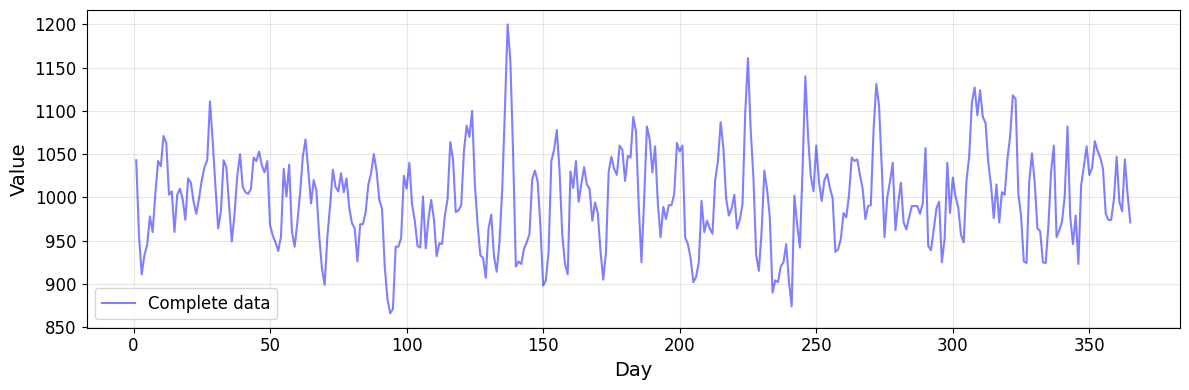

In [18]:
plot_time_series(orders)

Just by looking at the plot, the time series does not exhibit any obvious trends, structural breaks, seasonality, changing variability, or any other behavior that would violate the assumption of (weak) stationarity. Although the time-series plot may already suggest that the series is stationary, visual inspection alone is not sufficient to establish this with confidence. It is therefore good practice to complement the graphical analysis with appropriate **statistical tests for stationarity**, such as the **Augmented Dickey–Fuller (ADF)** test or **Kwiatkowski–Phillips–Schmidt–Shin (KPSS)** test. These provide more formal evidence as to whether the stationarity assumption required for a standard MA model is reasonable for the observed data. Omitting the details of those tests, we utilize implementations provided by the [statsmodels](https://www.statsmodels.org/) library.

First, the ADF test. It provides a formal test for whether a time series contains a unit root, which would indicate an important form of non-stationarity. Its null hypothesis $H_0$ is that the series has a unit root and is therefore non-stationary, while the alternative hypothesis $H_1$ is that the series is stationary (around the deterministic terms included in the test). Consequently, a small p-value, commonly below (0.05), provides evidence for rejecting the null hypothesis and supports treating the series as stationary; a larger p-value means that we do not have sufficient evidence to reject the presence of a unit root. We can run this test by applying the `adfuller()` method to our example time series.

In [19]:
result = adfuller(orders)

print(f"ADF test: p-value = {result[1]:3f}")

ADF test: p-value = 0.000000


A p-value of basically $0$ &mdash; ignoring any precision issues &mdash; is not surprising here. A time series generated by a standard finite $\text{MA}(3)$ process is stationary by construction, provided that the innovations are white noise with constant variance and the MA coefficients remain constant over time. Each observation is formed from only the current and three previous innovations, so its mean, variance, and autocovariance structure do not change over time; importantly, no restrictions on the magnitudes of the MA coefficients are needed for stationarity. Consequently, when applying the ADF test to a sufficiently long simulated $\text{MA}(3)$ series, we would generally expect to strongly reject the unit-root null hypothesis, often resulting in a very small p-value. 

Still, let's also run the KPSS test, which reverses the hypotheses used by the ADF test. Its null hypothesis $H_0$ is that the series is stationary (around a constant or deterministic trend, depending on the test specification), while the alternative hypothesis $H_1$ indicates non-stationarity due to a unit-root-type stochastic trend. Consequently, a small p-value, commonly below $0.05$, provides evidence against stationarity, whereas a larger p-value means that we do not have sufficient evidence to reject the assumption of stationarity. This makes the KPSS test a useful complement to the ADF test because the two tests approach the question of stationarity from opposite null hypotheses. Again, the [statsmodels](https://www.statsmodels.org/) library provides a method `kpss()` to run the test.

In [20]:
result = kpss(orders)

print(f"KPSS test: p-value = {result[1]:.3f}")

KPSS test: p-value = 0.100


/tmp/ipykernel_3177402/1995591335.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(orders)


Here, we actually get a warning that the p-value exceeds some internal range, since a p-value larger than $0.1$ are already a clear indicator that the time series is stationary.

Another common approach to better understand the nature of a time series is by means of **Autocorrelation Function (ACF) plot**. An ACF plot shows the correlation between a time series and **lagged versions of itself**. For each lag $k$, it plots $\rho(k)=\text{Corr}(x_t,x_{t-k})$, i.e., the correlation between all available observation pairs separated by k time steps. For example, for daily observations:

* **Lag 1:** correlation between observations one day apart
* **Lag 2:** correlation between observations two days apart
* **Lag 7:** correlation between observations one week apart
* ...

Each vertical bar represents the estimated autocorrelation at that lag. A value near (+1) means observations separated by that lag tend to move together, a value near $-1$ means they tend to move in opposite directions, and a value near $0$ means little linear association. Lag 0 is always $1$, since every series is perfectly correlated with itself. With this in mind, let's plot and inspect the ACF plot for the first $20$ lags for our example time series; we provide the auxiliary method `plot_acf_results()` for that.

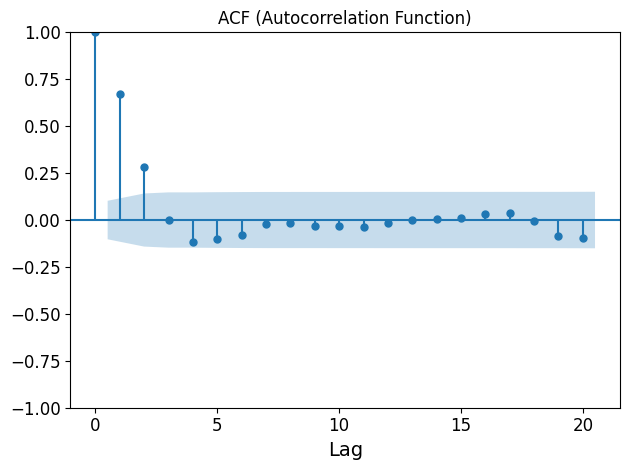

In [21]:
plot_acf_results(orders, lags=20)

The ACF plot is a particularly useful diagnostic when selecting and fitting an MA model because an $\text{MA}(q)$ process has a characteristic autocorrelation structure: observations can be correlated up to lag $q$, while the theoretical autocorrelation is zero for all larger lags. Consequently, the ACF of an $\text{MA}(q)$ process typically shows significant correlations for the first $q$ lags followed by a relatively sharp cutoff, with subsequent correlations fluctuating around zero. In practice, this pattern provides two important insights: it helps assess whether an MA model is a plausible description of the observed dependence structure and, importantly, provides guidance for selecting the model order $q$. When looking at the previous plot, we can quite clearly see the effect of the $\text{MA}(3)$ process that generated our example time series; only the first $3$ lags show a meaningful correlation.

**Side note:** For MA models, the **Partial Autocorrelation Function (PACF)** is typically less informative for selecting the model order than it is for AR models. While the PACF of an $\text{AR}(p)$ process has the useful property of theoretically cutting off after lag $p$, the PACF of an $\text{MA}(q)$ process generally decays gradually rather than exhibiting a clear cutoff at $q$. Consequently, the PACF usually does not provide a direct indication of the appropriate MA order. For identifying an MA model, the ACF is therefore the more useful diagnostic, while the PACF can still provide complementary information about the overall dependence structure.

In short, our EDA has shown &mdash; not very surprisingly &mdash; that our example time series is (weakly) stationary with a suggested lag order of $q=3$. So let's define the lag order as a variable and set its value to $3$. However, you are encouraged to increase or decrease the value and observe any effects on the final results.

In [22]:
q_orders = 3

Apart from just training an $\text{MA}(q)$ model and inspecting the learned parameters, we also want to have a look at the model's forecasting capabilities. To this end, let's define a forecasting horizon of $31$ days, meaning that we use the first $11$ months to fit the model, and the last model as a test set to compare it against the sequence of predicted observations; again, feel free to play with this value.

In [23]:
forecast_horizon = 31 

Using this forecast horizon, we can split our time series in the training part (first $11$ month) and the testing part (last month):

In [24]:
orders_train, orders_test = orders[:-forecast_horizon], orders[-forecast_horizon:]

We are now ready to train an MA model.

### "Manual" Approach

The "manual" approach for fitting an $\text{MA}(q)$ model simply refers to using our own implementation. Recall that all we needed for that was to call our `fit()` method with the time series and the value for $q$ as input argument. So let's do this and print the fitted values for all the model parameters; exactly like we did it previously for the toy time series:

In [25]:
model = fit(orders_train, q=q_orders)

print(f"Estimated mean:  \t{model['mu']:.3f}")
print(f"Estimated coeff: \t{model['theta']}")
print(f"Estimated sigma2:\t{model['sigma2']:.3f}")

Estimated mean:  	998.067
Estimated coeff: 	[0.89554515 0.56858819 0.18390496]
Estimated sigma2:	1383.521


As we can see, all the estimated parameters are rather close to the true value we used to generate the time series; note that $\varepsilon_t\sim N(0,40^2)$, so the true value for $\sigma_\varepsilon^2$ is $1,600$. Of course, values are arbitrarily unlikely to be identical since we still have to deal with randomness stemming from the white-noise shocks. If the time series would be longer, we could expect that the estimated parameter values would get closer to the true values. Again, the results are not unexpected since we are dealing with a synthetically generated dataset. Still, let's double-check if our model is invertible.

In [26]:
invertible, _ = is_invertible(model["theta"])

print("Invertible:", invertible)

Invertible: True


The last experiment concerns the model's forecasting capabilities. To this end, we call the `forecast_ma()` method to predict $31$ observations (here: days) into the future for our time series (i.e., the first $11$ month). We can then plot the result showing the complete time series with the true observations of the last month together with the predicted observations.

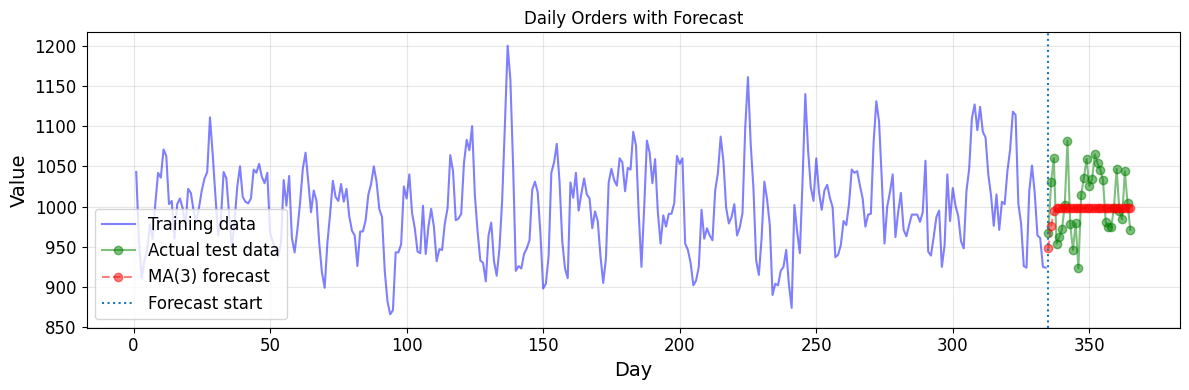

In [27]:
forecast = forecast_ma(model, steps=forecast_horizon)

plot_time_series(orders, model_name='MA', order=3, forecast=forecast, title="Daily Orders with Forecast")

As the results clearly show, pure $\text{MA}(q)$ models are generally **more suitable for short-term than long-term forecasting** because only the most recent $q$ estimated innovations can influence future predictions. As the forecast horizon increases, these known shocks gradually work their way through the model, while future shocks are unpredictable and therefore assigned their expected value of zero. Consequently, after $q$ steps, none of the previously observed shocks contributes to the point forecast, and the prediction becomes simply the estimated long-run mean, $\hat{\mu}$. Thus, MA models can be useful for capturing the short-lived effects of recent unexpected events, but by themselves provide little structure for distinguishing predictions far into the future.

### Practical Approach

While our own implementation for fitting $\text{MA}(q)$ seems to work overall fine, in practice, we typically make use of mature off-the-shelf implementations provided by libraries such as [statsmodels](https://www.statsmodels.org/). Apart from anything, they typically rely one more efficient solvers than basic Gradient Descent for the observations. For example, a pure $\text{MA}(q)$ model can conveniently be fitted using the [`ARIMA`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html) class provided by the [statsmodels](https://www.statsmodels.org/) library. Since an ARIMA model is specified by the order $(p,d,q)$, we simply set the autoregressive order $p=0$ and the differencing order $d=0$, leaving only the desired MA order $q$. In the code cell below, we use the [`ARIMA`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html) class to fit a $\text{MA}(q)$ model. We also use the `summary()` method to give us a compact represent of all the "things" the model has learned.

In [28]:
model = ARIMA(orders_train, order=(0, 0, q_orders)).fit()

print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  334
Model:                 ARIMA(0, 0, 3)   Log Likelihood               -1680.987
Date:                Tue, 25 Aug 2026   AIC                           3371.974
Time:                        18:16:03   BIC                           3391.030
Sample:                             0   HQIC                          3379.572
                                - 334                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        998.0712      5.629    177.297      0.000     987.038    1009.105
ma.L1          0.9102      0.052     17.594      0.000       0.809       1.012
ma.L2          0.5877      0.059      9.901      0.0

Additionally, we can also extract the relevant information to mimic the result from our manual implementation (see above).

In [29]:
mu_hat, theta_hat, sigma_hat = model.params[0], model.params[1:-1], model.params[-1]

print(f"Estimated mean:  \t{mu_hat:.3f}")
print(f"Estimated coeff: \t{theta_hat}")
print(f"Estimated sigma2:\t{sigma_hat:.3f}")

Estimated mean:  	998.071
Estimated coeff: 	[0.91015884 0.58773725 0.19355532]
Estimated sigma2:	1373.497


Overall, both models learn very similar parameters. Again, the results are very unlikely to be exactly identical due to the different numeric approaches to find the best values for all model parameters. And of course, we can also use this model for forecasting.

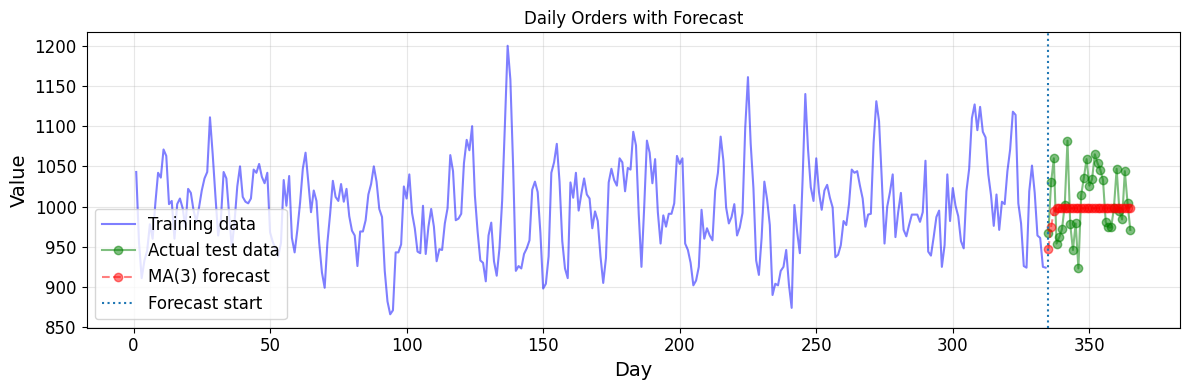

In [30]:
forecast = model.forecast(steps=forecast_horizon)

plot_time_series(orders, model_name='MA', order=3, forecast=forecast, title="Daily Orders with Forecast")

Unsurprisingly both forecasting plots look basically completely identical.

After fitting an $\text{MA}(q)$ model, it is important to perform **residual diagnostics** to assess whether the model has adequately captured the temporal structure in the data. If the model is well specified, the remaining residuals should behave approximately like **white noise**: they should fluctuate around zero, have a roughly constant variance, and &mdash; most importantly &mdash; show no meaningful autocorrelation. Examining residual plots, the residual ACF, and formal tests such as the **Ljung–Box test** can therefore reveal whether systematic patterns remain unexplained. If substantial autocorrelation is still present, this suggests that the chosen MA order or even the MA model itself may not adequately describe the time series.

Conveniently, the [`ARIMA`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html) class automatically computes all residuals for the observations in the training data. We can treat this sequence of residuals as a time series and use the auxiliary method `plot_time_series()` to plot the residuals.

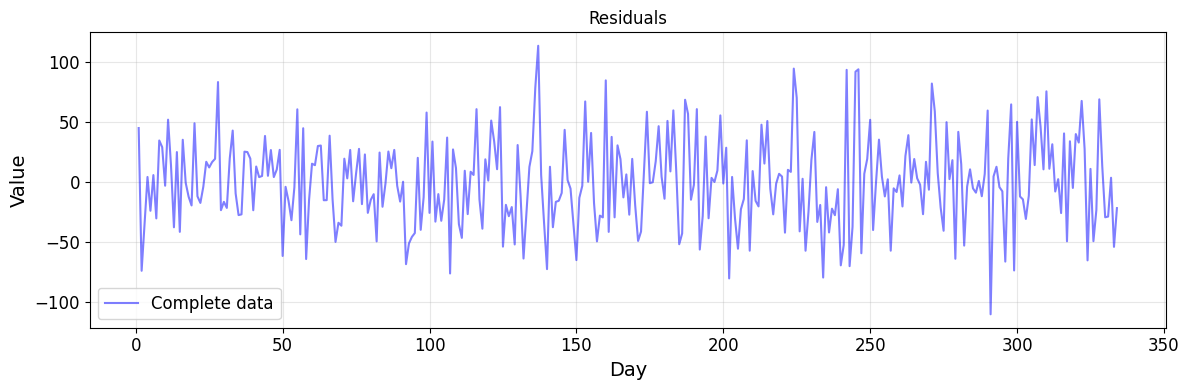

In [31]:
plot_time_series(model.resid, title="Residuals")

Using purely a visual inspection the residuals do look like random noise. Of course, this can be misleading, and we should therefore quantify this more appropriately. Residual diagnostics for an AR model typically focus on checking whether the remaining errors behave approximately like white noise, meaning that no systematic temporal structure remains unexplained by the model; common steps include:

* **Residual mean:** Compute the average of the residuals, which should be **close to zero**. A substantial non-zero mean indicates that the model systematically over- or underpredicts the observations.
* **PACF of residuals:** Plot the partial autocorrelations of the residuals. Ideally, the PACF values should be close to zero and mostly remain **inside the confidence bands**, indicating that no meaningful direct temporal dependencies remain.
* **Ljung-Box (LB) test:** Formally tests whether the residuals exhibit autocorrelation across a range of lags. The null hypothesis is that there is no residual autocorrelation, so a **large p-value** (commonly $p>0.05$) means there is insufficient evidence to reject the white-noise assumption, whereas a small p-value suggests that the model has left temporal structure unexplained.

For convenience, we provide the auxiliary method `residual_diagnostics()` which performs all these three steps and summarizes them into a single plot.

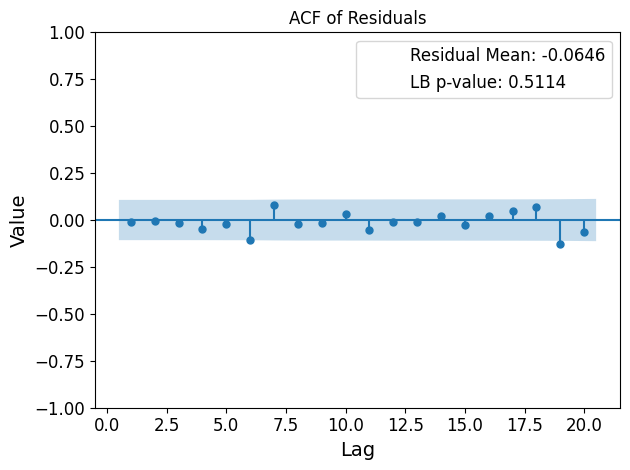

In [32]:
model = ARIMA(orders_train, order=(0, 0, q_orders)).fit()

residual_diagnostics(model, lags=20)

As expected &mdash; after all, we synthetically generated our time series using a $\text{MA}(3)$ model &mdash; all results show that our fitted model is properly specified:

* the residual mean is close to $0$
* almost all PACF values are inside the confidence band
* the p-value of the LB test is large; $0.511 \geq 0.05$

### Discussion

Moving Average (MA) models are an important building block of statistical time-series analysis because they provide a simple way to describe how unexpected shocks can influence a process over several subsequent periods. The estimated MA coefficients are themselves informative: they indicate the direction and strength with which recent innovations propagate through the series and how quickly their effects disappear. MA models therefore provide a useful framework for understanding short-term dependence caused by unexpected events.

As standalone forecasting models, however, pure $\text{MA}(q)$ models are used less frequently than more flexible alternatives, particularly when **long-term forecasts** are required. Since an $\text{MA}(q)$ model depends only on the current and previous $q$ innovations, all known shocks have worked their way through the model after $q$ forecast periods. Future innovations are unpredictable and have an expected value of zero, so forecasts beyond this horizon converge to the estimated mean $\hat{\mu}$. Pure MA models are therefore primarily suited to capturing and forecasting relatively short-lived dynamics.

Nevertheless, the **MA structure remains fundamental in practical time-series modeling** because it is incorporated into more sophisticated models such as **ARMA, ARIMA, and SARIMA**. These models combine the ability of MA components to capture short-term shock dynamics with autoregressive, differencing, and seasonal components that can represent persistence, non-stationarity, and recurring patterns. Thus, even though pure MA models may have limited usefulness for long-horizon forecasting, understanding their assumptions, coefficients, innovations, invertibility, and estimation provides an essential foundation for working with many of the most widely used classical time-series models.

---

### Summary

This notebook provided an in-depth introduction to **Moving Average (MA) models**, one of the fundamental classical approaches to time-series analysis. Despite major advances in forecasting with machine learning and neural networks, classical statistical models continue to have considerable practical relevance. They are computationally efficient, interpretable, well understood statistically, and often provide strong baselines for forecasting problems. More importantly, they offer a transparent framework for reasoning about temporal dependence and the role of unexpected shocks in the evolution of a time series.

Rather than treating MA models simply as formulas to be applied, the notebook developed their underlying concepts and assumptions in detail. This included stationarity, white-noise innovations, the finite influence of shocks, autocorrelation and the characteristic ACF structure of MA processes, as well as the important concept of **invertibility**. We also examined the mathematics behind parameter estimation, including conditional Maximum Likelihood Estimation, the construction of the likelihood and log-likelihood functions, profiling out the innovation variance, and the numerical optimization required to estimate the remaining MA parameters.

To connect the theory with its computational implementation, we developed an $\text{MA}(q)$ model **from scratch using only NumPy**. This made otherwise hidden steps explicit, including recursively reconstructing the unobserved innovations, evaluating the objective function, calculating its gradients, numerically updating the parameters, checking invertibility, and generating forecasts. A practical example using a synthetic time series further demonstrated the complete workflow from exploratory analysis and model identification to parameter estimation, forecasting, and residual diagnostics.

Pure MA models are primarily useful for modeling **short-lived effects of recent shocks**, and their forecasts quickly converge toward the estimated mean as the forecast horizon increases. Their importance, however, extends far beyond their use as standalone forecasting models. MA components form an essential part of more sophisticated and practically important models such as **ARMA, ARIMA, and SARIMA**. Developing a solid understanding of MA models therefore provides an important foundation for understanding these broader model families and for appreciating the statistical principles underlying classical time-series analysis.